# PHYS20762 Project 3: Monte Carlo Techniques – Neutron Transport and Scattering

This project investigates the shielding performance of various materials against thermal neutrons using Monte Carlo simulation techniques. Neutron transport is modelled as a probabilistic sequence of scattering and absorption events, governed by each material’s microscopic cross-sections.

The study focuses on three representative shielding materials: **Water**, **Lead**, and **Graphite**. These span a range of atomic masses and neutron interaction characteristics, providing insight into different moderation and attenuation behaviours.

The simulation framework incorporates:
- **Uniform and exponential random number generation** for simulating free-path lengths and event selection,
- **Isotropic scattering** to model angular redistribution after collisions,
- **Statistical analysis** to extract macroscopic transport properties such as attenuation length and transmission probability.

By combining these elements, the project aims to characterise how material composition influences neutron shielding effectiveness and to validate core principles of neutron-matter interactions through stochastic modelling.


## Environment Setup and Uniform Random Number Verification

The simulation begins with the setup of core scientific libraries for numerical computation, data handling, and visualisation. The plotting backend is configured to `'agg'`, a non-interactive mode suitable for batch processing and consistent figure rendering.

To validate the uniform random number generator used throughout the Monte Carlo simulations, we generate 60,000 values using `numpy.random.uniform()` over the interval $[0, 1)$. These values are binned into 50 intervals and plotted as a histogram. 

To assess statistical consistency, Poisson error bars are computed as $\sqrt{N}$ for each bin and overlaid on the histogram. A dotted reference line indicates the expected count per bin:

$$
\text{Expected count per bin} = \frac{60000}{50} = 1200
$$

Visual agreement between the observed frequencies and expected values suggests that the random number generator produces an approximately uniform distribution, as required for unbiased stochastic sampling.

Reliable uniform sampling is essential in Monte Carlo methods, as it underpins both the spatial and angular randomness of simulated neutron paths.



In [1]:
# --- Backend Setup (must come first) ---
import matplotlib
matplotlib.use('agg')  # Set non-interactive backend early to avoid warnings

# --- Imports and Setup ---
import matplotlib.pyplot as plt             # For 2D and 3D plotting
from mpl_toolkits.mplot3d import Axes3D     # Enables 3D plotting in matplotlib
import numpy as np                          # For numerical computations and RNG
import math                                 # For basic math operations
import scipy.constants as const             # Provides access to physical constants
from tqdm.notebook import tnrange           # For progress bars in notebooks
import pandas as pd                         # For tabular data handling
from pandas.plotting import table           # To embed tables inside plots

# Close any previously opened figures to prevent backend switch warning
plt.close('all')

# Enable inline plotting (for Jupyter Notebook environments)
%matplotlib inline


# --- 1. Generate Uniform Random Numbers ---
# Generate 60,000 values uniformly distributed in the interval [0, 1)
U = np.random.uniform(size=60000)


# --- 2. Plot Histogram of Random Numbers ---
# Bin the values into a histogram with 50 bins
bins = 50
counts, bin_edges = np.histogram(U, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)  # Poisson error: sqrt(N) per bin

# Plot histogram with error bars and a reference line at expected bin count
plt.figure(figsize=(8, 5))
plt.bar(bin_centers, counts, width=np.diff(bin_edges), color='white',
        edgecolor='red', alpha=0.6, label='Histogram')
plt.errorbar(bin_centers, counts, yerr=errors, fmt='o', color='black',
             markersize=2, capsize=3, label='Poisson Error Bars')
plt.axhline(1200, linestyle='dotted', color='blue', linewidth=1.5,
            label='Expected Count per Bin (1200)')

plt.title('Histogram of Uniformly Distributed Random Numbers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'tqdm'

## 2D Scatter Plot of Uniform Random $(x, y)$ Pairs

To further assess the behaviour of the uniform random number generator, we reinterpret a one-dimensional array of values as two-dimensional coordinate pairs. Every even-indexed element is treated as an $x$-coordinate, and every odd-indexed element as the corresponding $y$-coordinate.

This yields 30,000 $(x, y)$ points, which are plotted within the unit square $[0, 1] \times [0, 1]$ to visually inspect the distribution. The resulting scatter plot exhibits a uniform and dense coverage of the domain, with no apparent clustering or voids.

Such spatial uniformity is important in Monte Carlo simulations involving neutron transport, where two-dimensional sampling underlies directional random walks and scattering angle generation. While this visual test does not rigorously establish statistical independence, it provides initial confirmation that the generator behaves consistently in multiple dimensions.


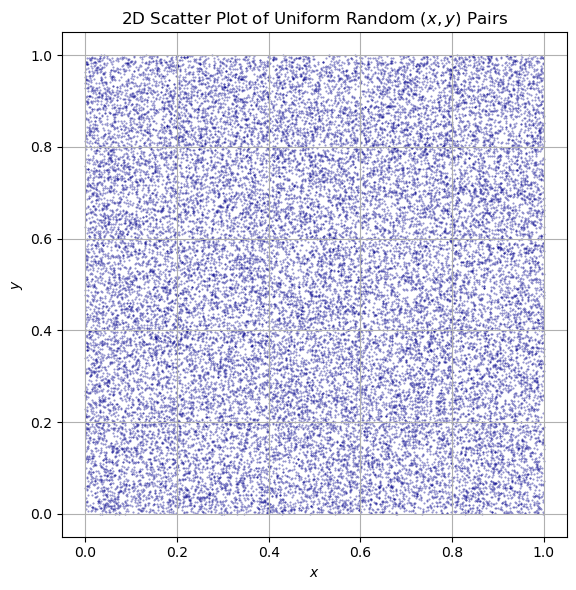

In [ ]:
# --- 3. 2D Scatter Plot of Uniform Random (x, y) Pairs ---

# Interpret the uniform array U as interleaved x and y coordinates
x = U[0::2]  # Take even-indexed values as x-coordinates
y = U[1::2]  # Take odd-indexed values as y-coordinates

# Create scatter plot to visually assess 2D uniformity
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=0.2, alpha=0.5, color='darkblue')
plt.title('2D Scatter Plot of Uniform Random $(x, y)$ Pairs')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid(True)
plt.axis('square')  # Ensure equal aspect ratio for both axes
plt.tight_layout()
plt.show()

## 3D Scatter Plot of Uniform Random Points in the Unit Cube

To examine the performance of the random number generator in three dimensions, a uniform array is reinterpreted as a sequence of $$(x, y, z)$$ triplets. To ensure proper alignment, the total number of elements is truncated to a multiple of three.

A subset of 20,000 points is visualised within the unit cube $[0, 1]^3$. The resulting scatter plot displays a dense, uniform distribution throughout the volume, with no observable clustering, voids, or directional structure.

Establishing spatial uniformity in three dimensions is critical for Monte Carlo neutron transport simulations, where isotropic scattering and spatially random event propagation rely on high-quality multidimensional sampling. While visual inspection cannot confirm full statistical independence, it provides a necessary preliminary check before applying the random number stream to physics-driven modelling.




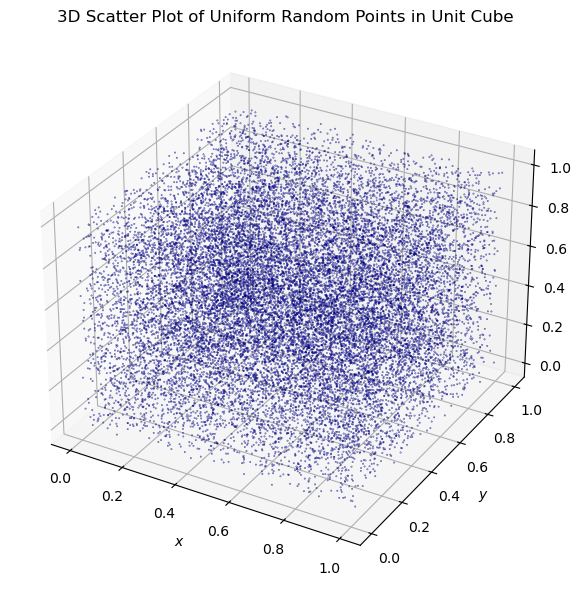

In [ ]:
# --- 4. 3D Scatter Plot from Uniform Data ---

# Truncate U to a multiple of 3 to create (x, y, z) triplets
U = U[:len(U) - (len(U) % 3)]

# Reshape U into x, y, z components
x = U[0::3]
y = U[1::3]
z = U[2::3]

# Use a reduced sample size for performance and clarity in plotting
sample_size = 20000
x, y, z = x[:sample_size], y[:sample_size], z[:sample_size]

# Create 3D scatter plot of uniformly distributed points within the unit cube
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=0.1, alpha=0.8, color='navy')

ax.set_title('3D Scatter Plot of Uniform Random Points in Unit Cube')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

plt.tight_layout()
plt.show()

## Custom Linear Congruential Generator (`randssp`)

To demonstrate the consequences of using low-quality pseudo-random number generators, we implement a basic Linear Congruential Generator (LCG) through the custom function `randssp()`. This classical algorithm generates values recursively via:

$$
x_{n+1} = (a x_n + c) \mod m
$$

Although simple and computationally efficient, LCGs are known to produce statistically correlated outputs, particularly in higher-dimensional applications. These correlations can lead to visible structural patterns, known as *spectral artifacts*, which compromise the validity of stochastic sampling.

In the accompanying 3D scatter plot, samples generated by `randssp()` exhibit planar alignments and non-uniform filling of the unit cube. This highlights the importance of using statistically robust random number generators in Monte Carlo neutron transport simulations, where uncorrelated, isotropic sampling is essential for accurate physical modelling.

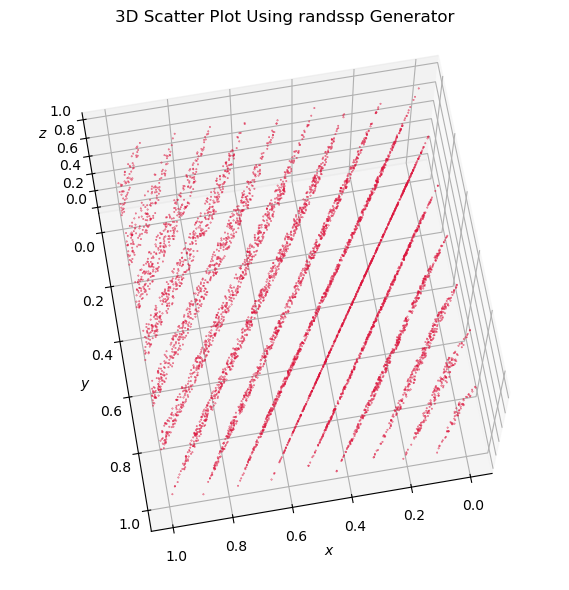

In [ ]:
# --- 5. Custom RNG: Linear Congruential Generator (LCG) ---
def randssp(p, q, seed=123456789):
    """
    Custom random number generator using a linear congruential method (LCG).
    Produces a (p × q) array of pseudo-random numbers in [0, 1).

    Parameters:
        p (int): number of rows (dimensions)
        q (int): number of columns (samples per dimension)
        seed (int): initial seed value for reproducibility

    Returns:
        np.ndarray: (p × q) array of pseudo-random values in [0, 1)
    """
    m = 2**31             # Modulus
    a = 2**16 + 3         # Multiplier
    c = 0                 # Increment
    x = seed              # Initial seed value

    r = np.zeros((p, q))
    for l in range(q):
        for k in range(p):
            x = (a * x + c) % m
            r[k, l] = x / m

    return r


# --- 6. 3D Scatter Plot of randssp-generated Points ---

# Generate 6000 samples across 3 dimensions using the custom RNG
A = randssp(3, 6000)
x, y, z = A[0, :], A[1, :], A[2, :]

# Plot the points to reveal any structured artifacts
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=0.1, alpha=0.9, color='crimson')
ax.view_init(elev=70, azim=80)  # Camera angle for better 3D depth

ax.set_title('3D Scatter Plot Using randssp Generator')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')
plt.tight_layout()
plt.show()

## Shield Class and Exponential Path Sampling

To simulate neutron transport through different materials, we define a `shield` class that encapsulates both microscopic nuclear data and macroscopic material properties relevant to interaction probabilities.

For each shielding material, the class computes:
- **Microscopic cross-sections** for absorption and scattering, converted from barns to cm²,
- **Number density** via \( n = \frac{\rho N_A}{M} \), where \( \rho \) is the density and \( M \) the molar mass,
- **Mean free paths (MFP)** for absorption, scattering, and total interactions,
- **Interaction probabilities**, defining the likelihood of absorption versus scattering.

Instances are created for three representative materials:
- **Water**: a hydrogen-rich moderator with a high scattering cross-section,
- **Lead**: a dense, heavy element that favours neutron absorption,
- **Graphite**: a carbon-based material with low absorption, often used as a moderator.

In addition, the `Exponential_distribution()` function generates random path lengths drawn from an exponential distribution:

$$
P(x) = \frac{1}{\lambda} e^{-x / \lambda}
$$

This distribution models the probability of a neutron travelling a distance \( x \) before undergoing an interaction, with \( \lambda \) corresponding to the mean free path in the medium. It is a fundamental component of stochastic particle tracking in Monte Carlo transport simulations.



In [ ]:
# --- Define a Shielding Material Class ---

class shield:
    def __init__(self, Absorption, Scattering, Density, Molar_mass, name):
        """
        Represents a neutron shielding material using microscopic and macroscopic properties.

        Parameters:
        Absorption (float): Microscopic absorption cross-section in barns
        Scattering (float): Microscopic scattering cross-section in barns
        Density (float): Material density in g/cm^3
        Molar_mass (float): Molar mass in g/mol
        name (str): Material name for identification
        """

        # Convert cross-sections from barns (1 barn = 1e-24 cm^2) to cm^2
        self.Absorption = Absorption * 1e-24
        self.Scattering = Scattering * 1e-24
        self.Density = Density
        self.Molar_mass = Molar_mass
        self.name = name

        # Calculate number density: n = ρ * N_A / M
        self.n = Density * const.Avogadro / Molar_mass

        # Compute mean free paths (MFP) for different interactions
        self.MFP_Absorption = 1 / (self.n * self.Absorption)
        self.MFP_Scattering = 1 / (self.n * self.Scattering)
        self.MFP_Total = 1 / (self.n * (self.Absorption + self.Scattering))

        # Probabilities of absorption vs. scattering
        self.Absorption_prob = self.Absorption / (self.Absorption + self.Scattering)
        self.Scattering_prob = self.Scattering / (self.Absorption + self.Scattering)


# Instantiate shield objects for each material using tabulated properties
Water = shield(0.6652, 103.0, 1.00, 18.0153, "Water")
Lead = shield(0.158, 11.221, 11.35, 207.2, "Lead")
Graphite = shield(0.0045, 4.74, 1.67, 12.011, "Graphite")


# --- Generate Exponentially Distributed Step Lengths ---

def Exponential_distribution(lambdaa, n):
    """
    Generates n random samples from an exponential distribution with mean lambdaa.

    Parameters:
    lambdaa (float): Mean free path (scale parameter)
    n (int): Number of samples to generate

    Returns:
    np.ndarray: Array of path lengths following exp(-x / lambdaa)
    """
    u = np.random.uniform(size=n)        # Uniform random numbers in [0, 1)
    s = -lambdaa * np.log(u)             # Inverse transform sampling from exponential distribution
    return s

## Estimating Attenuation Length from Exponential Path Distributions

To validate the exponential attenuation of neutrons in a shielding material, we simulate absorption events in water using path lengths sampled from an exponential distribution defined by its microscopic mean free path.

### Simulation and Data Aggregation

- The simulation is repeated 20 times, each with 10,000 sampled step lengths.
- Path lengths are binned into 30 intervals spanning 0–200 cm.
- For each bin, the **mean frequency** and **standard deviation** are computed across trials.

### Attenuation Fit Methodology

Assuming ideal exponential attenuation, the mean frequency distribution should follow:

$$
f(x) \propto \exp\left(-\frac{x}{\lambda}\right)
\quad \Rightarrow \quad
\log(f(x)) \propto -\frac{x}{\lambda}
$$

By plotting $\log(f(x))$ against position, the attenuation length $\lambda$ is extracted from the negative inverse of the fitted slope. A **weighted linear regression** is used, with weights based on the relative statistical uncertainty in each bin.

### Visualisation

- The histogram displays the spatial distribution of mean neutron path lengths.
- The log-frequency plot illustrates exponential decay, overlaid with a fitted line.
- A tabulated summary reports the estimated attenuation length with its associated uncertainty.

This approach offers a quantitative benchmark for verifying exponential absorption behaviour, confirming that the simulated transport dynamics align with theoretical expectations for thermal neutrons in water.

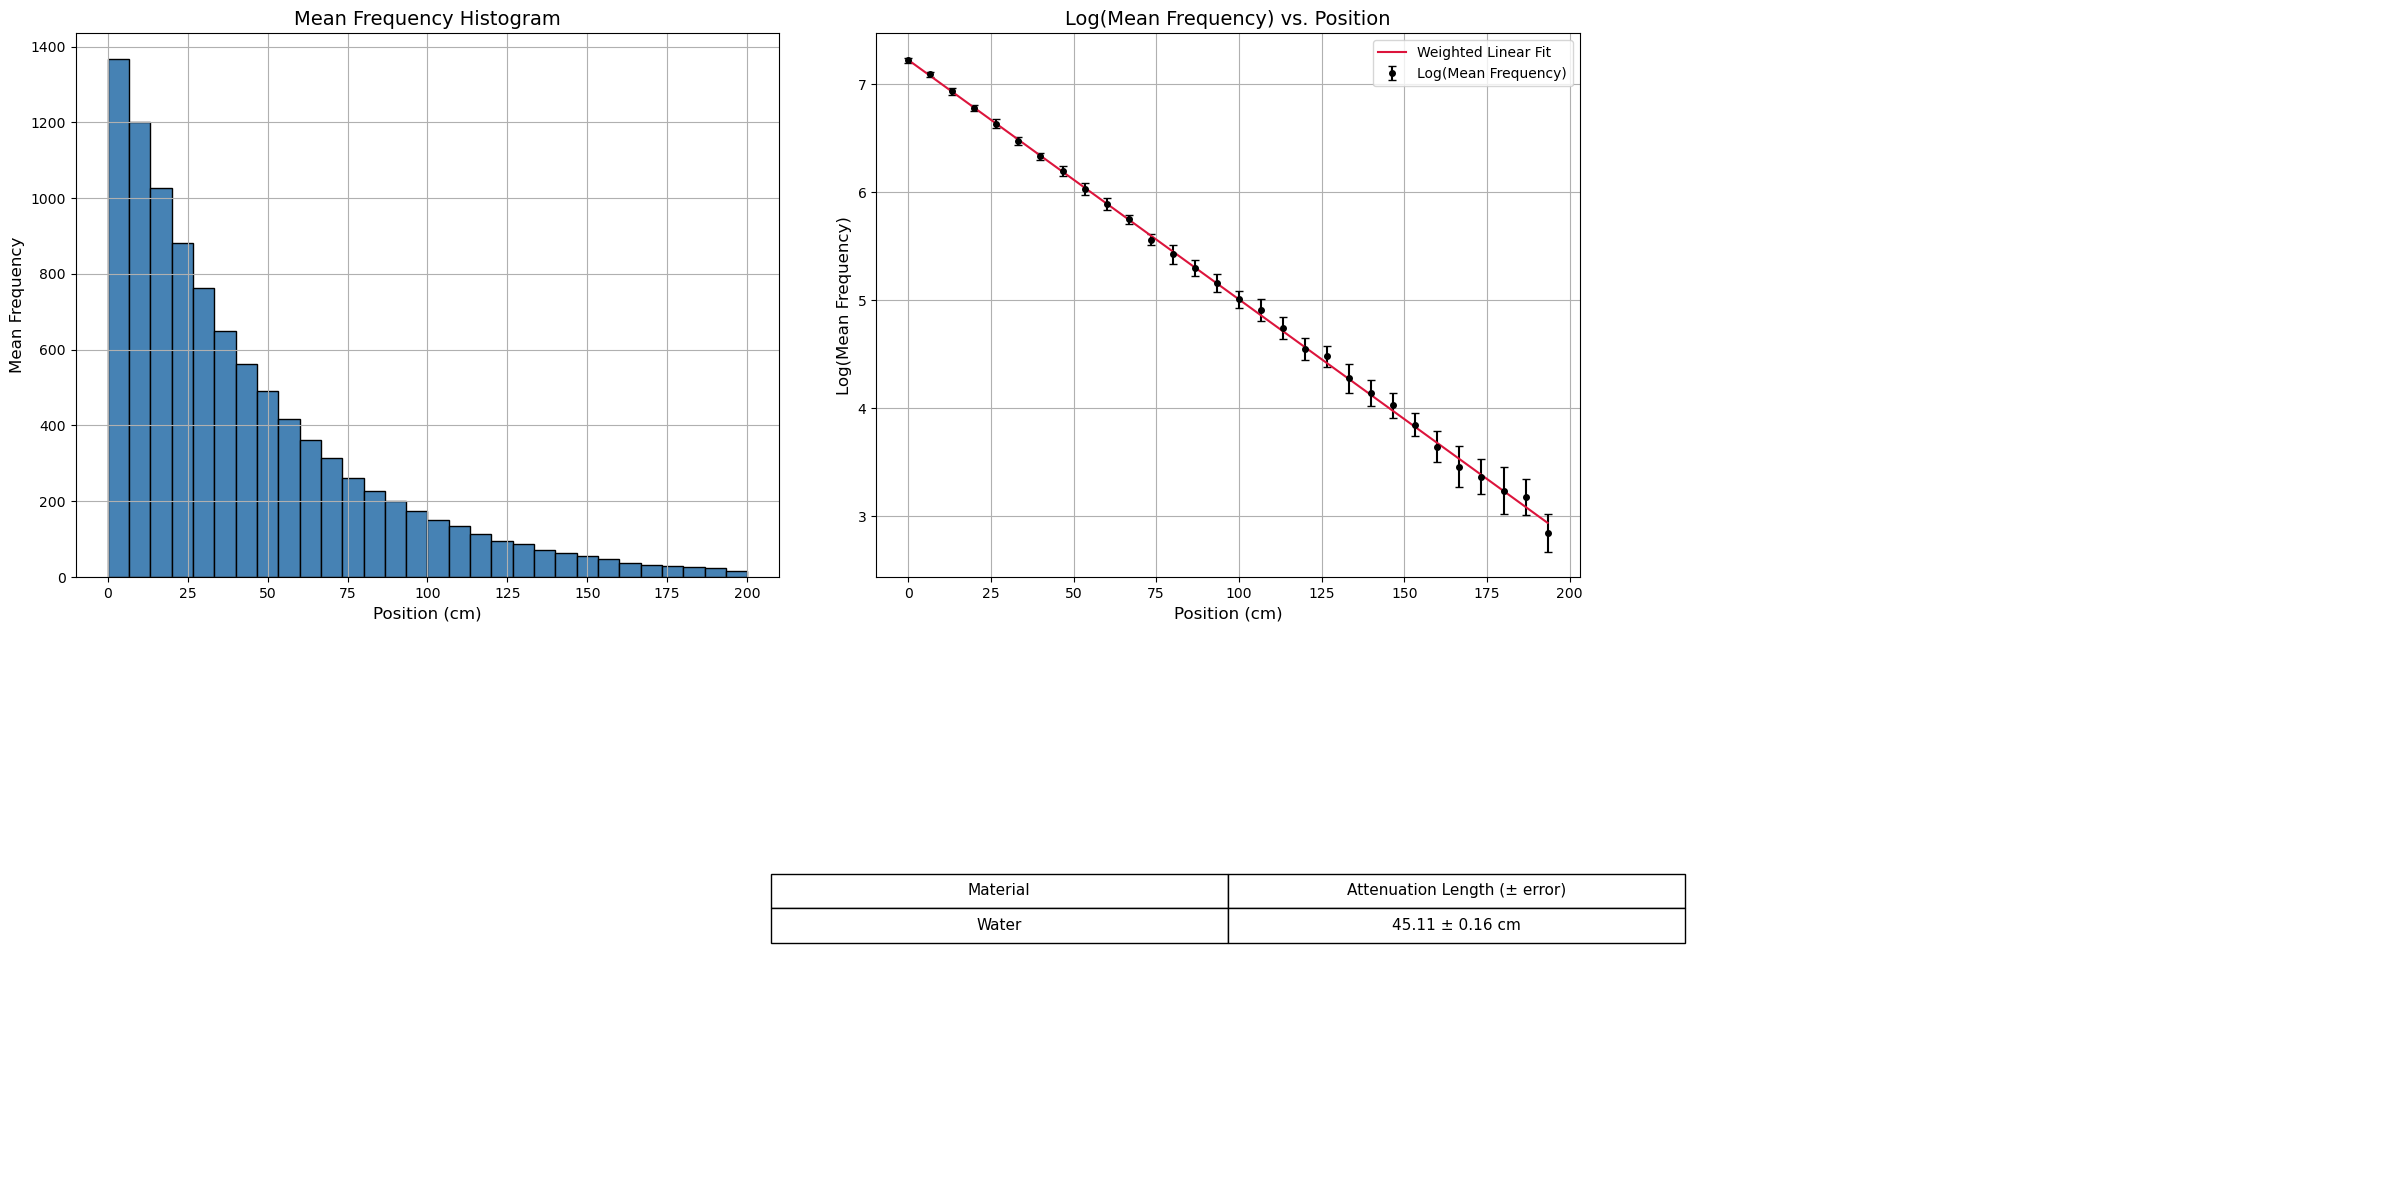

In [ ]:
# --- Estimate Attenuation Length and Display Results (Cleaned and Styled) ---

# Simulate histogram data across multiple trials
frequency = np.zeros((20, 30))
attenLengthValues = np.array([])

for x in range(20):
    s = Exponential_distribution(Water.MFP_Absorption, 10000)
    frequency[x, :], position_bins = np.histogram(s, bins=30, range=(0, 200))

position_bins = position_bins[:-1]

# Compute statistics
mean_frequency = np.mean(frequency, axis=0)
std_frequency = np.std(frequency, axis=0)

# Remove zero bins to avoid log(0)
nonzero_mask = mean_frequency > 0
position_bins = position_bins[nonzero_mask]
mean_frequency = mean_frequency[nonzero_mask]
std_frequency = std_frequency[nonzero_mask]
error = std_frequency / mean_frequency

# Perform weighted linear fit in log-space
log_fit, Covariance = np.polyfit(np.log(mean_frequency), position_bins, 1, w=1/error, cov=True)
gradient = log_fit[0]
intercept = log_fit[1]
attenLength = -gradient
uncertainty = np.sqrt(np.diag(Covariance)[0])  # Standard error

# Format results with uncertainty
atten_with_uncertainty = f"{attenLength:.2f} ± {uncertainty:.2f} cm"

# Create DataFrame for table output
df = pd.DataFrame({
    "Material": [Water.name],
    "Attenuation Length (± error)": [atten_with_uncertainty]
})

# --- Plotting: Cleaned and Balanced Layout ---
fig, axs = plt.subplots(2, 3, figsize=(24, 12))

# Histogram plot
axs[0, 0].bar(position_bins, mean_frequency,
              width=position_bins[1] - position_bins[0],
              color='steelblue', edgecolor='black', align='edge')
axs[0, 0].set_xlabel("Position (cm)", fontsize=12)
axs[0, 0].set_ylabel("Mean Frequency", fontsize=12)
axs[0, 0].set_title("Mean Frequency Histogram", fontsize=14)
axs[0, 0].tick_params(labelsize=10)
axs[0, 0].grid(True)

# Log-fit plot
axs[0, 1].errorbar(position_bins, np.log(mean_frequency), yerr=error,
                   fmt='o', capsize=3, color='black', label='Log(Mean Frequency)', markersize=4)
fit_line = (position_bins - intercept) / gradient
axs[0, 1].plot(position_bins, fit_line, color='crimson', label='Weighted Linear Fit')
axs[0, 1].set_xlabel("Position (cm)", fontsize=12)
axs[0, 1].set_ylabel("Log(Mean Frequency)", fontsize=12)
axs[0, 1].set_title("Log(Mean Frequency) vs. Position", fontsize=14)
axs[0, 1].legend(fontsize=10)
axs[0, 1].tick_params(labelsize=10)
axs[0, 1].grid(True)

# Empty axes for spacing
axs[0, 2].axis('off')
axs[1, 0].axis('off')
axs[1, 2].axis('off')

# Results table
axs[1, 1].axis('off')
mpl_table = axs[1, 1].table(cellText=df.values, colLabels=df.columns,
                            cellLoc='center', loc='center')
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(11)
mpl_table.scale(1.3, 1.6)

plt.tight_layout()
plt.show()

## Demonstration of Incorrect Isotropic Sampling: Clustering Along the $z$-Axis

This example illustrates a common mistake in three-dimensional Monte Carlo simulations: sampling the polar angle $\theta$ uniformly over $[0, \pi]$ in an attempt to generate points uniformly distributed over the surface of a sphere.

### Why This Is Incorrect

In spherical coordinates, the differential surface area element is given by:

$$
dA = \sin\theta \, d\theta \, d\phi
$$

A uniform distribution in $\theta$ results in oversampling near the poles (aligned with the $z$-axis) and undersampling near the equator. This introduces a **non-uniform angular bias**, which becomes apparent in the 3D scatter plot as clustering along the vertical axis.

### Pedagogical Purpose

This implementation is included deliberately to expose a subtle but critical pitfall:

> Uniform sampling of $\theta$ does **not** yield uniform sampling on the surface of a sphere.

Such biases can invalidate simulations of isotropic physical processes, such as neutron scattering, where angular symmetry is essential.

### Correct Approach

To ensure uniform sampling on a sphere, one must instead sample $\cos\theta$ uniformly over $[-1, 1]$, then invert via the arccosine:

```python
cos_theta = np.random.uniform(-1, 1)
theta = np.arccos(cos_theta)


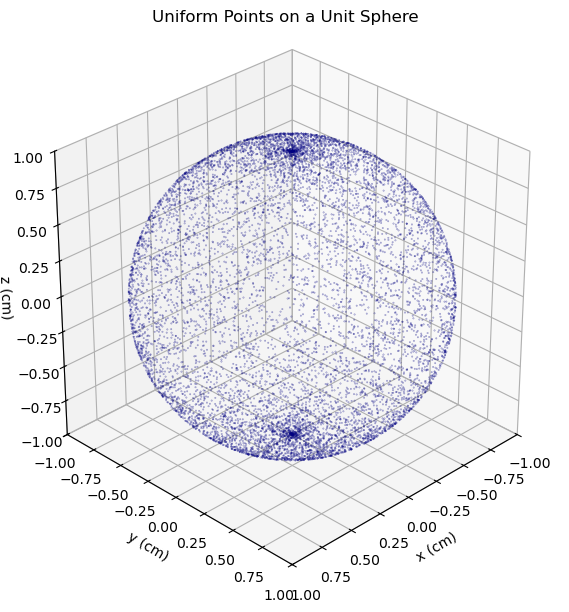

In [ ]:
def generate_random_sphere_grouping(n):
    """
    Generates n points uniformly distributed over the surface of a sphere.
    Uses correct isotropic sampling by generating uniform azimuthal (phi)
    and cosine of the polar angle (cos(theta)).

    Returns:
        x, y, z (arrays): Cartesian coordinates of points on the unit sphere.
    """
    radius = 1
    phi_angle = np.random.uniform(0, 2 * math.pi, size=n)       # Azimuthal angle ∈ [0, 2π)
    theta_angle = np.random.uniform(0, math.pi, size=n)         # θ ∈ [0, π) sampled uniformly (incorrect for isotropy)

    x = radius * np.sin(theta_angle) * np.cos(phi_angle)
    y = radius * np.sin(theta_angle) * np.sin(phi_angle)
    z = radius * np.cos(theta_angle)

    return x, y, z



x,y,z = generate_random_sphere_grouping(10000)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=0.1, alpha=0.5, color='navy')

ax.set_title('Uniform Points on a Unit Sphere')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

## Isotropic Neutron Scattering: Directional Uniformity and Exponential Step Lengths

Neutron transport in materials is governed by two fundamental stochastic processes:
1. The direction in which a neutron scatters after a collision,
2. The distance it travels before its next interaction.

We simulate both using isotropic vector sampling in spherical coordinates.

### 1. Directional Isotropy on the Unit Sphere

The function `generate_random_sphere(n)` generates $n$ unit vectors with directions uniformly distributed over the surface of a sphere. To ensure true angular isotropy:
- The **azimuthal angle** $\phi$ is sampled uniformly over $[0, 2\pi)$,
- The **cosine of the polar angle** $\cos\theta$ is sampled uniformly over $[-1, 1]$ to account for the non-uniform surface area in spherical coordinates.

This sampling preserves equal probability over equal solid angles, a physical requirement for modelling isotropic scattering in neutron transport.

### 2. Exponentially Distributed Step Lengths

The function `generate_random_exponential_sphere(\lambda, n)` extends the above by associating each isotropic direction with a step length drawn from the exponential distribution:

$$
P(r) = \frac{1}{\lambda} \, e^{-r/\lambda}
$$

This models the probabilistic distance a neutron travels before colliding, where $\lambda$ is the total mean free path (MFP) of the medium.

### Visual Interpretation

- The **first 3D plot** displays points on a unit sphere, confirming angular isotropy.
- The **second plot** shows spatial displacements scaled by exponentially distributed magnitudes (with $\lambda = 45$ cm), producing a spherically symmetric "cloud" of collision points.

Together, these routines capture the essential physical ingredients of free-flight and isotropic scattering, forming the core of neutron transport modelling in Monte Carlo simulations.

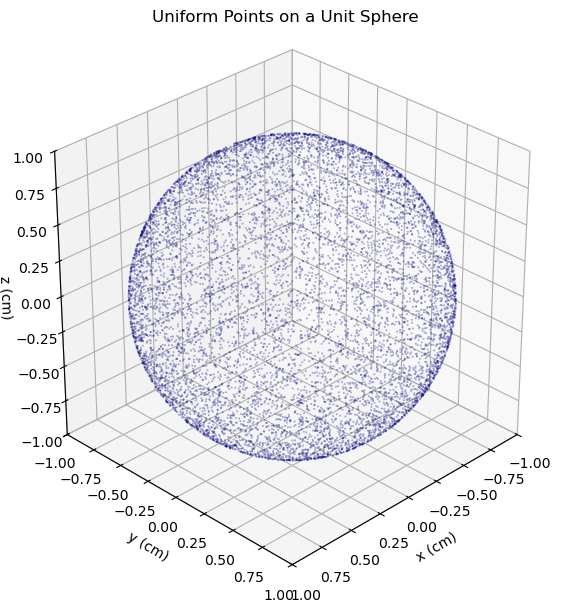

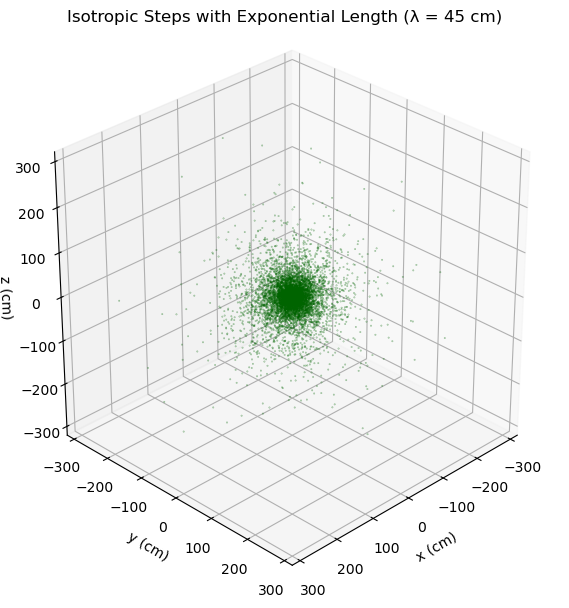

In [ ]:
# --- Exponential Distribution Function ---
def Exponential_distribution(lambdaa, n):
    u = np.random.uniform(size=n)
    s = -lambdaa * np.log(u)
    return s

# --- Uniform Unit Vectors on a Sphere ---
def generate_random_sphere(n):
    """
    Generates n isotropic unit vectors (uniformly distributed on the unit sphere).
    """
    radius = 1
    phi_angle = np.random.uniform(0, 2 * math.pi, size=n)
    cos = np.random.uniform(-1, 1, size=n)
    theta_angle = np.arccos(cos)

    x = radius * np.sin(theta_angle) * np.cos(phi_angle)
    y = radius * np.sin(theta_angle) * np.sin(phi_angle)
    z = radius * np.cos(theta_angle)

    return x, y, z

# --- Isotropic Vectors with Exponential Lengths ---
def generate_random_exponential_sphere(lambdaa, n):
    """
    Generates n 3D vectors with exponential length and isotropic directions.
    """
    radius = Exponential_distribution(lambdaa, n)
    phi_angle = np.random.uniform(0, 2 * math.pi, size=n)
    cos = np.random.uniform(-1, 1, size=n)
    theta_angle = np.arccos(cos)

    x = radius * np.sin(theta_angle) * np.cos(phi_angle)
    y = radius * np.sin(theta_angle) * np.sin(phi_angle)
    z = radius * np.cos(theta_angle)

    return x, y, z

# === Plot: Uniform Points on a Unit Sphere ===
x, y, z = generate_random_sphere(10000)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=0.1, alpha=0.5, color='navy')

ax.set_title('Uniform Points on a Unit Sphere')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

# === Plot: Exponential Isotropic Steps ===
x, y, z = generate_random_exponential_sphere(45, 10000)  # λ = 45 cm for water

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=0.1, alpha=0.5, color='darkgreen')

ax.set_title('Isotropic Steps with Exponential Length (λ = 45 cm)')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')

r_max = np.max(np.abs([x, y, z]))
ax.set_xlim([-r_max, r_max])
ax.set_ylim([-r_max, r_max])
ax.set_zlim([-r_max, r_max])
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()


## 3D Random Walk Visualisation of a Single Neutron

This simulation illustrates the path of a single thermal neutron as it propagates through shielding materials — **Water**, **Lead**, and **Graphite** — modelled as homogeneous slabs of thickness \( L = 10 \,\text{cm} \). The neutron undergoes a stochastic random walk until one of three terminal outcomes:

- **Absorption**: the neutron is absorbed within the material,
- **Reflection**: the neutron exits the slab back through the entry side \((x < 0)\),
- **Transmission**: the neutron passes through and exits the far side \((x > L)\).

### Modelling Approach

- Each neutron begins at the origin \((0, 0, 0)\),
- Step lengths are drawn from an **exponential distribution** with mean free path \(\lambda\), which depends on both the absorption and scattering cross-sections,
- Scattering directions are sampled **isotropically** over the unit sphere,
- At each interaction point, a uniform random number determines whether the neutron is absorbed based on the material's macroscopic absorption probability.

### Visualisation and Interpretation

- Each subplot shows the 3D trajectory of one neutron per material, colour-coded by material type,
- The x-axis corresponds to slab depth and determines whether the neutron is absorbed, reflected, or transmitted,
- The final outcome is shown in the plot title.

These visualisations qualitatively highlight differences in neutron transport across materials. **Lead**, being dense and highly absorptive, suppresses long paths. **Graphite**, with minimal absorption, permits extended diffusion. **Water** shows intermediate behaviour dominated by frequent scattering.


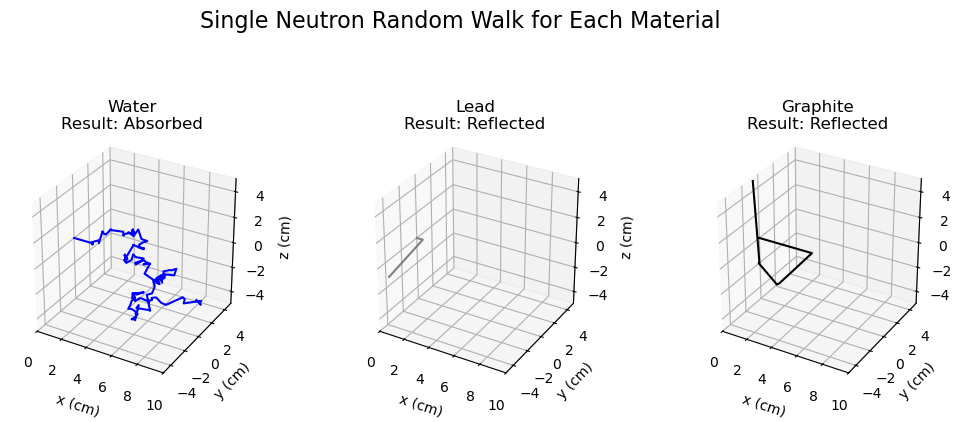

In [ ]:
# --- Neutron Random Walk Simulation in 3D ---

def walk_visualisation(n, absorb_prob, length, MFP):
    """
    Simulates 3D random walks of n neutrons through a slab.
    Each neutron continues moving until absorbed, reflected, or transmitted.

    Parameters:
        n (int): number of neutrons
        absorb_prob (float): probability of absorption
        length (float): slab width (cm)
        MFP (float): mean free path in the material (cm)

    Returns:
        paths: list of [x, y, z] coordinate sequences for each neutron
    """
    paths = [ [[], [], []] for _ in range(n) ]  # Initialise [x, y, z] per neutron

    # Initial positions at origin
    x = np.zeros(n)
    y = np.zeros(n)
    z = np.zeros(n)
    positions = np.vstack((x, y, z)).T

    # Record initial positions
    for i in range(n):
        paths[i][0].append(x[i])
        paths[i][1].append(y[i])
        paths[i][2].append(z[i])

    # First forward step along x
    x = Exponential_distribution(MFP, n)
    positions = np.vstack((x, y, z)).T
    absorb = np.random.uniform(size=n)
    alive = np.ones(n, dtype=bool)

    while np.any(alive):
        # Log positions
        for i in range(n):
            if alive[i]:
                paths[i][0].append(positions[i, 0])
                paths[i][1].append(positions[i, 1])
                paths[i][2].append(positions[i, 2])

        # Neutron fate decisions
        alive[positions[:, 0] < 0] = False            # Reflected
        alive[positions[:, 0] > length] = False       # Transmitted
        alive[absorb < absorb_prob] = False           # Absorbed

        alive_indices = np.where(alive)[0]
        if len(alive_indices) == 0:
            break

        # Move surviving neutrons
        dx, dy, dz = generate_random_exponential_sphere(MFP, len(alive_indices))
        positions[alive_indices, 0] += dx
        positions[alive_indices, 1] += dy
        positions[alive_indices, 2] += dz

        # Resample absorption chance
        absorb[alive_indices] = np.random.uniform(size=len(alive_indices))

    return paths


# --- Plot Random Walks for One Neutron in Each Material ---

def plot_single_walks_subplots(water_path, lead_path, graphite_path, slab_length):
    """
    Plots 3D random walk paths of one neutron in Water, Lead, and Graphite.

    Parameters:
        *_path: [x, y, z] lists of a single neutron's path
        slab_length (float): width of slab in cm
    """
    fig = plt.figure(figsize=(12, 5))
    fig.suptitle("Single Neutron Random Walk for Each Material", fontsize=16)

    paths = [
        (water_path, "Water", "blue"),
        (lead_path, "Lead", "gray"),
        (graphite_path, "Graphite", "black")
    ]

    for i, (path, material_name, color) in enumerate(paths):
        x, y, z = path
        ax = fig.add_subplot(1, 3, i+1, projection='3d')
        ax.plot(x, y, z, color=color)

        # Neutron outcome
        end_x = x[-1]
        if end_x < 0:
            status = "Reflected"
        elif end_x > slab_length:
            status = "Transmitted"
        else:
            status = "Absorbed"

        ax.set_title(f"{material_name}\nResult: {status}", fontsize=12)
        ax.set_xlabel("x (cm)")
        ax.set_ylabel("y (cm)")
        ax.set_zlabel("z (cm)")

        # Set axis limits for visibility
        ax.set_xlim(0, slab_length)
        ax.set_ylim([-5, 5])
        ax.set_zlim([-5, 5])
        ax.set_box_aspect([1, 1, 1])  # Equal aspect ratio

    # Adjust subplot spacing and avoid z-label clipping
    plt.subplots_adjust(top=0.85, wspace=0.4)
    plt.show()


# --- Run the Simulation and Plot Results ---

neutron_number = 1
length = 10  # slab length in cm

# Simulate paths for one neutron in each material
water_path = walk_visualisation(neutron_number, Water.Absorption_prob, length, Water.MFP_Total)[0]
lead_path = walk_visualisation(neutron_number, Lead.Absorption_prob, length, Lead.MFP_Total)[0]
graphite_path = walk_visualisation(neutron_number, Graphite.Absorption_prob, length, Graphite.MFP_Total)[0]

# Plot all three walks side by side
plot_single_walks_subplots(water_path, lead_path, graphite_path, slab_length=length)




## Single-Slab Monte Carlo Shielding Simulation

This section models the interaction of thermal neutrons with a homogeneous shielding slab of fixed thickness using a Monte Carlo method. We simulate how neutrons are either **transmitted**, **absorbed**, or **reflected** depending on the nuclear properties of the material.

### Methodology

For each material:
- A population of $n = 10{,}000$ neutrons is incident perpendicularly on a slab of thickness $L = 10\,\text{cm}$.
- The free path between scattering events is sampled from an exponential distribution:

$$
P(x) = \frac{1}{\lambda} \exp\left(-\frac{x}{\lambda}\right),
$$

where $\lambda$ is the total mean free path in the material.

- At each interaction:
  - A neutron is absorbed with probability $P_{\text{abs}}$.
  - Otherwise, it scatters in an isotropic direction and takes a new exponentially sampled step.

Each neutron is classified as:
- **Transmitted** if $x > L$,
- **Reflected** if $x < 0$,
- **Absorbed** if $0 \leq x \leq L$ and the neutron is absorbed during the simulation.

The simulation is repeated 10 times to estimate statistical uncertainties.

### Results and Interpretation

- **Pie charts** display the average outcome proportions for each material.
- **Error annotations** show the standard deviation of each outcome across repeated trials.
- A **summary table** consolidates the transmission, absorption, and reflection fractions with associated uncertainties.

### Physical Insights

- **Water** has a high scattering cross-section, promoting frequent direction changes and increased absorption likelihood.
- **Lead**, due to its high density and strong absorption cross-section, shows minimal transmission and high absorption.
- **Graphite**, with low absorption and moderate scattering, favours longer neutron paths and therefore higher transmission probabilities.

These simulations illustrate how fundamental nuclear properties influence shielding behaviour and demonstrate the effectiveness of Monte Carlo methods in modelling neutron transport.

progress:   0%|          | 0/10 [00:00<?, ?it/s]

progress:   0%|          | 0/10 [00:00<?, ?it/s]

progress:   0%|          | 0/10 [00:00<?, ?it/s]

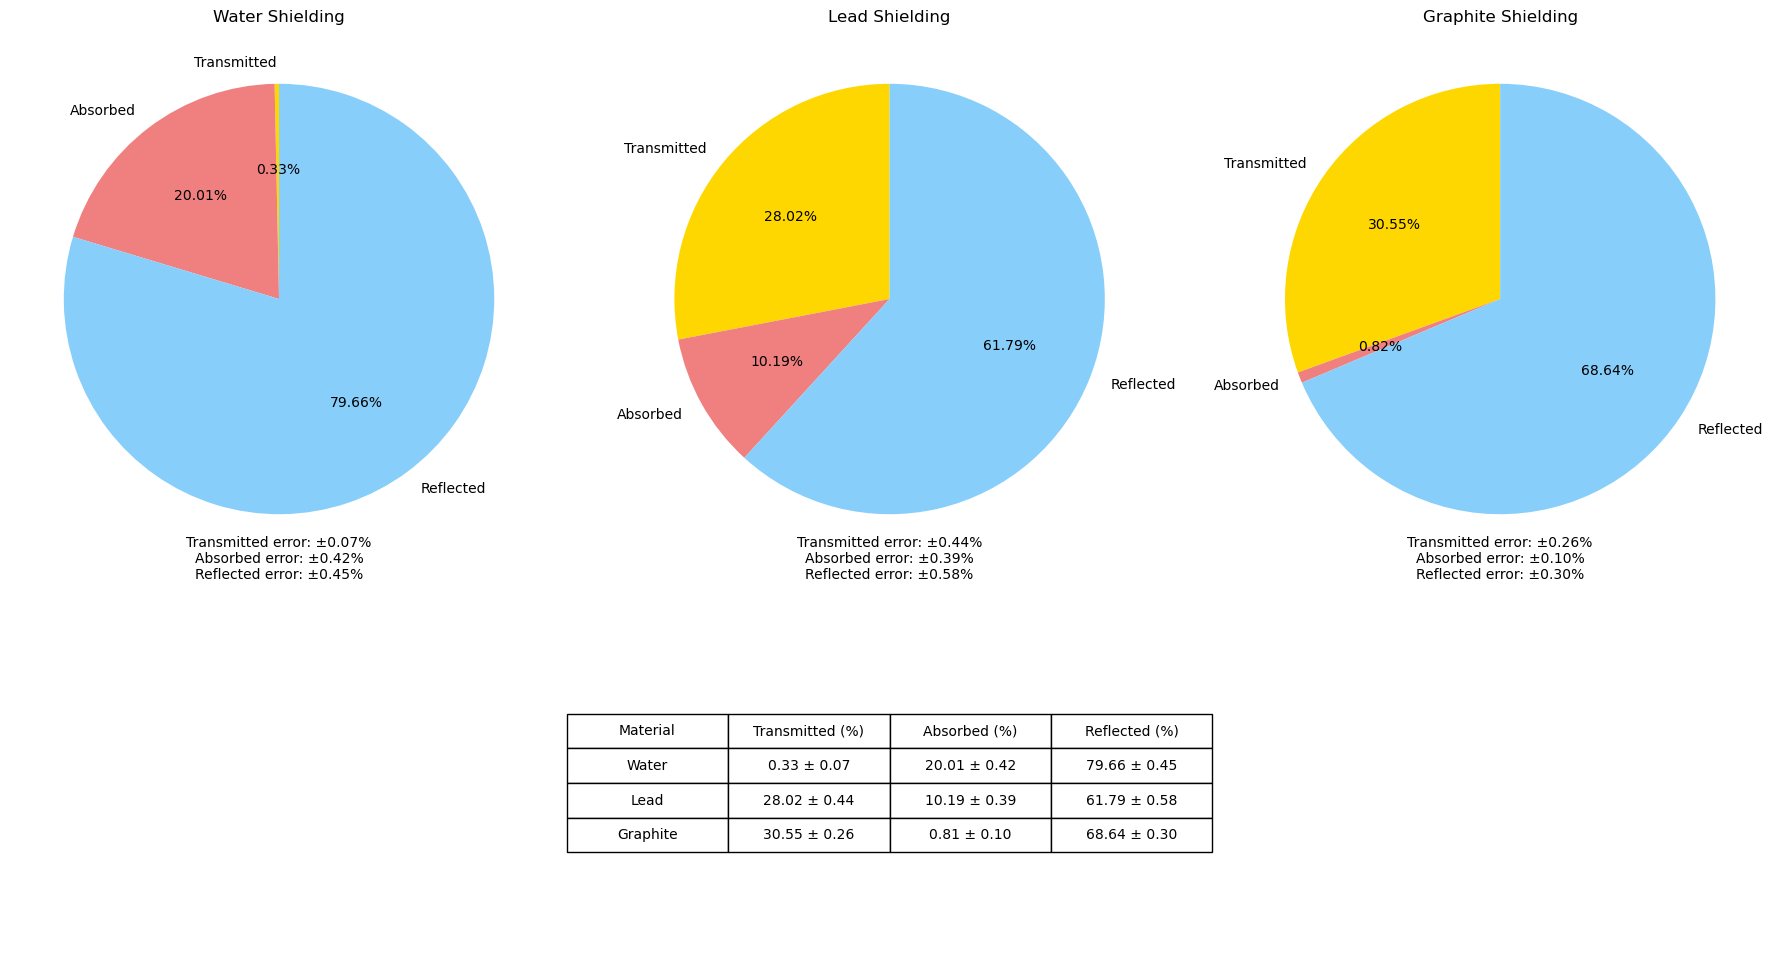

In [ ]:
def Single_slab_shielding(n, absorb_prob, length, MFP, repeats, disable=True):
    transmitted = np.zeros(repeats)
    absorbed = np.zeros(repeats)
    reflected = np.zeros(repeats)

    for i in tnrange(repeats, desc = "progress", disable=disable):
        neutrons = Exponential_distribution(MFP, n)
        absorb = np.random.uniform(size=n)

        while len(neutrons) > 0:
            # Count fate of neutrons
            transmitted[i] += np.count_nonzero(neutrons > length)
            reflected[i] += np.count_nonzero(neutrons < 0)

            in_slab = (neutrons > 0) & (neutrons < length)
            absorbed[i] += np.count_nonzero(absorb[in_slab] < absorb_prob)

            # Create mask of neutrons to keep
            keep_mask = ((absorb > absorb_prob) & in_slab)

            # Filter both arrays consistently
            neutrons = neutrons[keep_mask]

            # Resample scattering
            radius = Exponential_distribution(MFP, len(neutrons))    
            #phi_angle = np.random.uniform(0, math.pi * 2, size=len(neutrons))
            cos = np.random.uniform(-1, 1, size=len(neutrons))
            #theta_angle = np.arccos(cos)

            neutrons += radius * cos
            absorb = np.random.uniform(size=len(neutrons))
    means = [
        np.mean(transmitted) / n,
        np.mean(absorbed) / n,
        np.mean(reflected) / n]
    
    stds = [
        np.std(transmitted) / n,
        np.std(absorbed) / n,
        np.std(reflected) / n]
    return means, stds


def plot_shielding_results():
    """
    Runs shielding simulations for Water, Lead, and Graphite,
    then displays results as pie charts with standard deviation text
    and a summary table of transmission, absorption, and reflection rates.
    """
    length = 10
    repeats = 10
    neutron_number = 10000

    # Run simulations for each material
    water_ratio = Single_slab_shielding(neutron_number, Water.Absorption_prob, length, Water.MFP_Total, repeats, disable=False)
    lead_ratio = Single_slab_shielding(neutron_number, Lead.Absorption_prob, length, Lead.MFP_Total, repeats, disable=False)
    graphite_ratio = Single_slab_shielding(neutron_number, Graphite.Absorption_prob, length, Graphite.MFP_Total, repeats, disable=False)

    labels = ['Transmitted', 'Absorbed', 'Reflected']
    colors = ['gold', 'lightcoral', 'lightskyblue']
    fig, axs = plt.subplots(2, 3, figsize=(18, 10), gridspec_kw={'height_ratios': [2, 1]})

    # Helper function to plot a pie chart and show errors
    def plot_pie_chart(ax, ratios, stds, material_name):
        ax.pie(ratios, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
        ax.set_title(f'{material_name} Shielding')
        text = '\n'.join(f"{label} error: ±{std * 100:.2f}%" for label, std in zip(labels, stds))
        ax.text(0, -1.3, text, ha='center', fontsize=10)

    # Plot pie charts for each material
    plot_pie_chart(axs[0, 0], water_ratio[0], water_ratio[1], 'Water')
    plot_pie_chart(axs[0, 1], lead_ratio[0], lead_ratio[1], 'Lead')
    plot_pie_chart(axs[0, 2], graphite_ratio[0], graphite_ratio[1], 'Graphite')

    # Helper to combine mean and std as string
    def combine(val, err):
        return f"{val*100:.2f} ± {err*100:.2f}"

    # Construct table data
    materials = ['Water', 'Lead', 'Graphite']
    combined_data = {
        "Material": materials,
        "Transmitted (%)": [
            combine(water_ratio[0][0], water_ratio[1][0]),
            combine(lead_ratio[0][0], lead_ratio[1][0]),
            combine(graphite_ratio[0][0], graphite_ratio[1][0])
        ],
        "Absorbed (%)": [
            combine(water_ratio[0][1], water_ratio[1][1]),
            combine(lead_ratio[0][1], lead_ratio[1][1]),
            combine(graphite_ratio[0][1], graphite_ratio[1][1])
        ],
        "Reflected (%)": [
            combine(water_ratio[0][2], water_ratio[1][2]),
            combine(lead_ratio[0][2], lead_ratio[1][2]),
            combine(graphite_ratio[0][2], graphite_ratio[1][2])
        ],
    }

    df = pd.DataFrame(combined_data)

    # Hide lower subplots and insert table in the middle
    axs[1, 0].axis('off')
    axs[1, 1].axis('off')
    axs[1, 2].axis('off')
    table_ax = axs[1, 1]
    table_ax.axis('off')

    mpl_table = table_ax.table(cellText=df.values, colLabels=df.columns,
                               cellLoc='center', loc='center')
    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(10)
    mpl_table.scale(1.2, 1.5)

    plt.tight_layout()
    plt.show()

plot_shielding_results()

## Shielding Behaviour vs. Slab Thickness

We extend the single-slab shielding simulation to evaluate how the slab thickness affects the likelihood of neutron transmission, absorption, and reflection across three materials: **Water**, **Lead**, and **Graphite**.

### Methodology

- Neutrons are simulated through slabs of thickness ranging from **1 to 20 cm**, sampled uniformly in 20 steps.
- For each thickness $L$, the shielding process is repeated over **10 Monte Carlo trials** using $n = 10{,}000$ neutrons per trial.
- At each step, we compute the **mean** and **standard deviation** of the following outcome probabilities:
  - **Transmission**: neutron exits the far side ($x > L$),
  - **Absorption**: neutron absorbed inside the slab,
  - **Reflection**: neutron exits the near side ($x < 0$).

### Physics of Neutron Attenuation

As slab thickness increases:
- **Transmission** probability decreases due to increased path length and interaction opportunities.
- **Absorption** and **reflection** probabilities typically increase, depending on the material’s nuclear cross-sections.

The exponential nature of attenuation is governed by:

$$
T(L) \propto \exp\left(-\frac{L}{\lambda}\right),
$$

where $\lambda$ is the total mean free path. This exponential law will later be verified quantitatively through curve fitting.

### Output Structure

Simulation results are organised as:
- `transmission_data[material] = (\mu_T, \sigma_T)` in percent,
- `absorption_data[material] = (\mu_A, \sigma_A)`,
- `reflection_data[material] = (\mu_R, \sigma_R)`,

where each tuple contains arrays of means and standard deviations across the thickness range. These results form the basis for visualising attenuation trends and estimating macroscopic shielding parameters in the following sections.


In [ ]:
# --- Simulate Neutron Shielding vs. Slab Thickness ---

def plot_slab_shielding_vs_thickness(materials, thicknesses_cm, n=10000, repeats=10):
    """
    Runs slab shielding simulations over a range of thicknesses for multiple materials.

    Parameters:
        materials (dict): {name: shield object}
        thicknesses_cm (array): slab thickness values to simulate [cm]
        n (int): number of neutrons per simulation
        repeats (int): number of Monte Carlo trials per thickness

    Returns:
        transmission_data (dict): {material: (means%, stds%)}
        absorption_data   (dict): {material: (means%, stds%)}
        reflection_data   (dict): {material: (means%, stds%)}
    """
    transmission_data = {}
    absorption_data = {}
    reflection_data = {}

    for name, mat in materials.items():
        trans_means, trans_stds = [], []
        abs_means, abs_stds = [], []
        refl_means, refl_stds = [], []

        for L in thicknesses_cm:
            # Run shielding simulation for current thickness
            mean, std = Single_slab_shielding(n, mat.Absorption_prob, L, mat.MFP_Total, repeats)
            mean = np.array(mean) * 100  # Convert to %
            std = np.array(std) * 100

            trans_means.append(mean[0])
            trans_stds.append(std[0])
            abs_means.append(mean[1])
            abs_stds.append(std[1])
            refl_means.append(mean[2])
            refl_stds.append(std[2])

        # Store results per material
        transmission_data[name] = (np.array(trans_means), np.array(trans_stds))
        absorption_data[name]   = (np.array(abs_means), np.array(abs_stds))
        reflection_data[name]   = (np.array(refl_means), np.array(refl_stds))

    return transmission_data, absorption_data, reflection_data


# --- Run Simulation for Thickness Range ---

materials = {
    'Water': Water,
    'Lead': Lead,
    'Graphite': Graphite
}

thickness_range_cm = np.linspace(1, 20, 20)  # 1 to 20 cm in 20 steps
transmission_data, absorption_data, reflection_data = plot_slab_shielding_vs_thickness(
    materials, thickness_range_cm)


## Attenuation Curve Fitting and Material Comparison

To quantitatively assess neutron shielding performance, we fit an exponential attenuation model to the simulated transmission data. The goal is to extract the **attenuation length** $\lambda$ for each material, which characterises the exponential decay of neutron flux with slab thickness.

### Modelling Approach

From theory, transmission probability through a slab of thickness $L$ follows:

$$
T(L) \propto \exp\left(-\frac{L}{\lambda}\right)
\quad \Rightarrow \quad
\ln(T) = -\frac{L}{\lambda} + \text{const}
$$

This linear relationship between $\ln(T)$ and $L$ allows us to extract $\lambda$ by fitting a straight line to the logarithmic transmission data.

### Procedure
For each material:
- We plot **Transmission**, **Absorption**, and **Reflection** as functions of thickness, each with error bars showing Monte Carlo uncertainty.
- For transmission data, we compute:
  - $\ln(T)$ and its propagated uncertainty,
  - A **weighted linear least squares fit** using inverse error as weights,
  - The fitted slope is $-1/\lambda$.

### Goodness of Fit

The quality of each fit is evaluated using the **chi-squared statistic**:

$$
\chi^2 = \sum_i \left( \frac{\ln(T_i^{\text{obs}}) - \ln(T_i^{\text{fit}})}{\sigma_{\ln T_i}} \right)^2
\quad , \quad
\chi^2_{\mathrm{red}} = \frac{\chi^2}{\text{DoF}}
$$

Where DoF is the number of data points minus two (for the slope and intercept).

### Output

- The left three plots per row show the shielding outcomes vs. thickness.
- The rightmost plot shows the **log-transmission fit** with annotated values of:
  - Attenuation length $\lambda \pm \text{error}$,
  - $\chi^2$ and reduced $\chi^2_{\mathrm{red}}$.
- A final table summarises fitted $\lambda$ values and fit quality metrics for all materials.

This provides a rigorous quantitative characterisation of shielding behaviour, complementing the earlier stochastic visualisations.



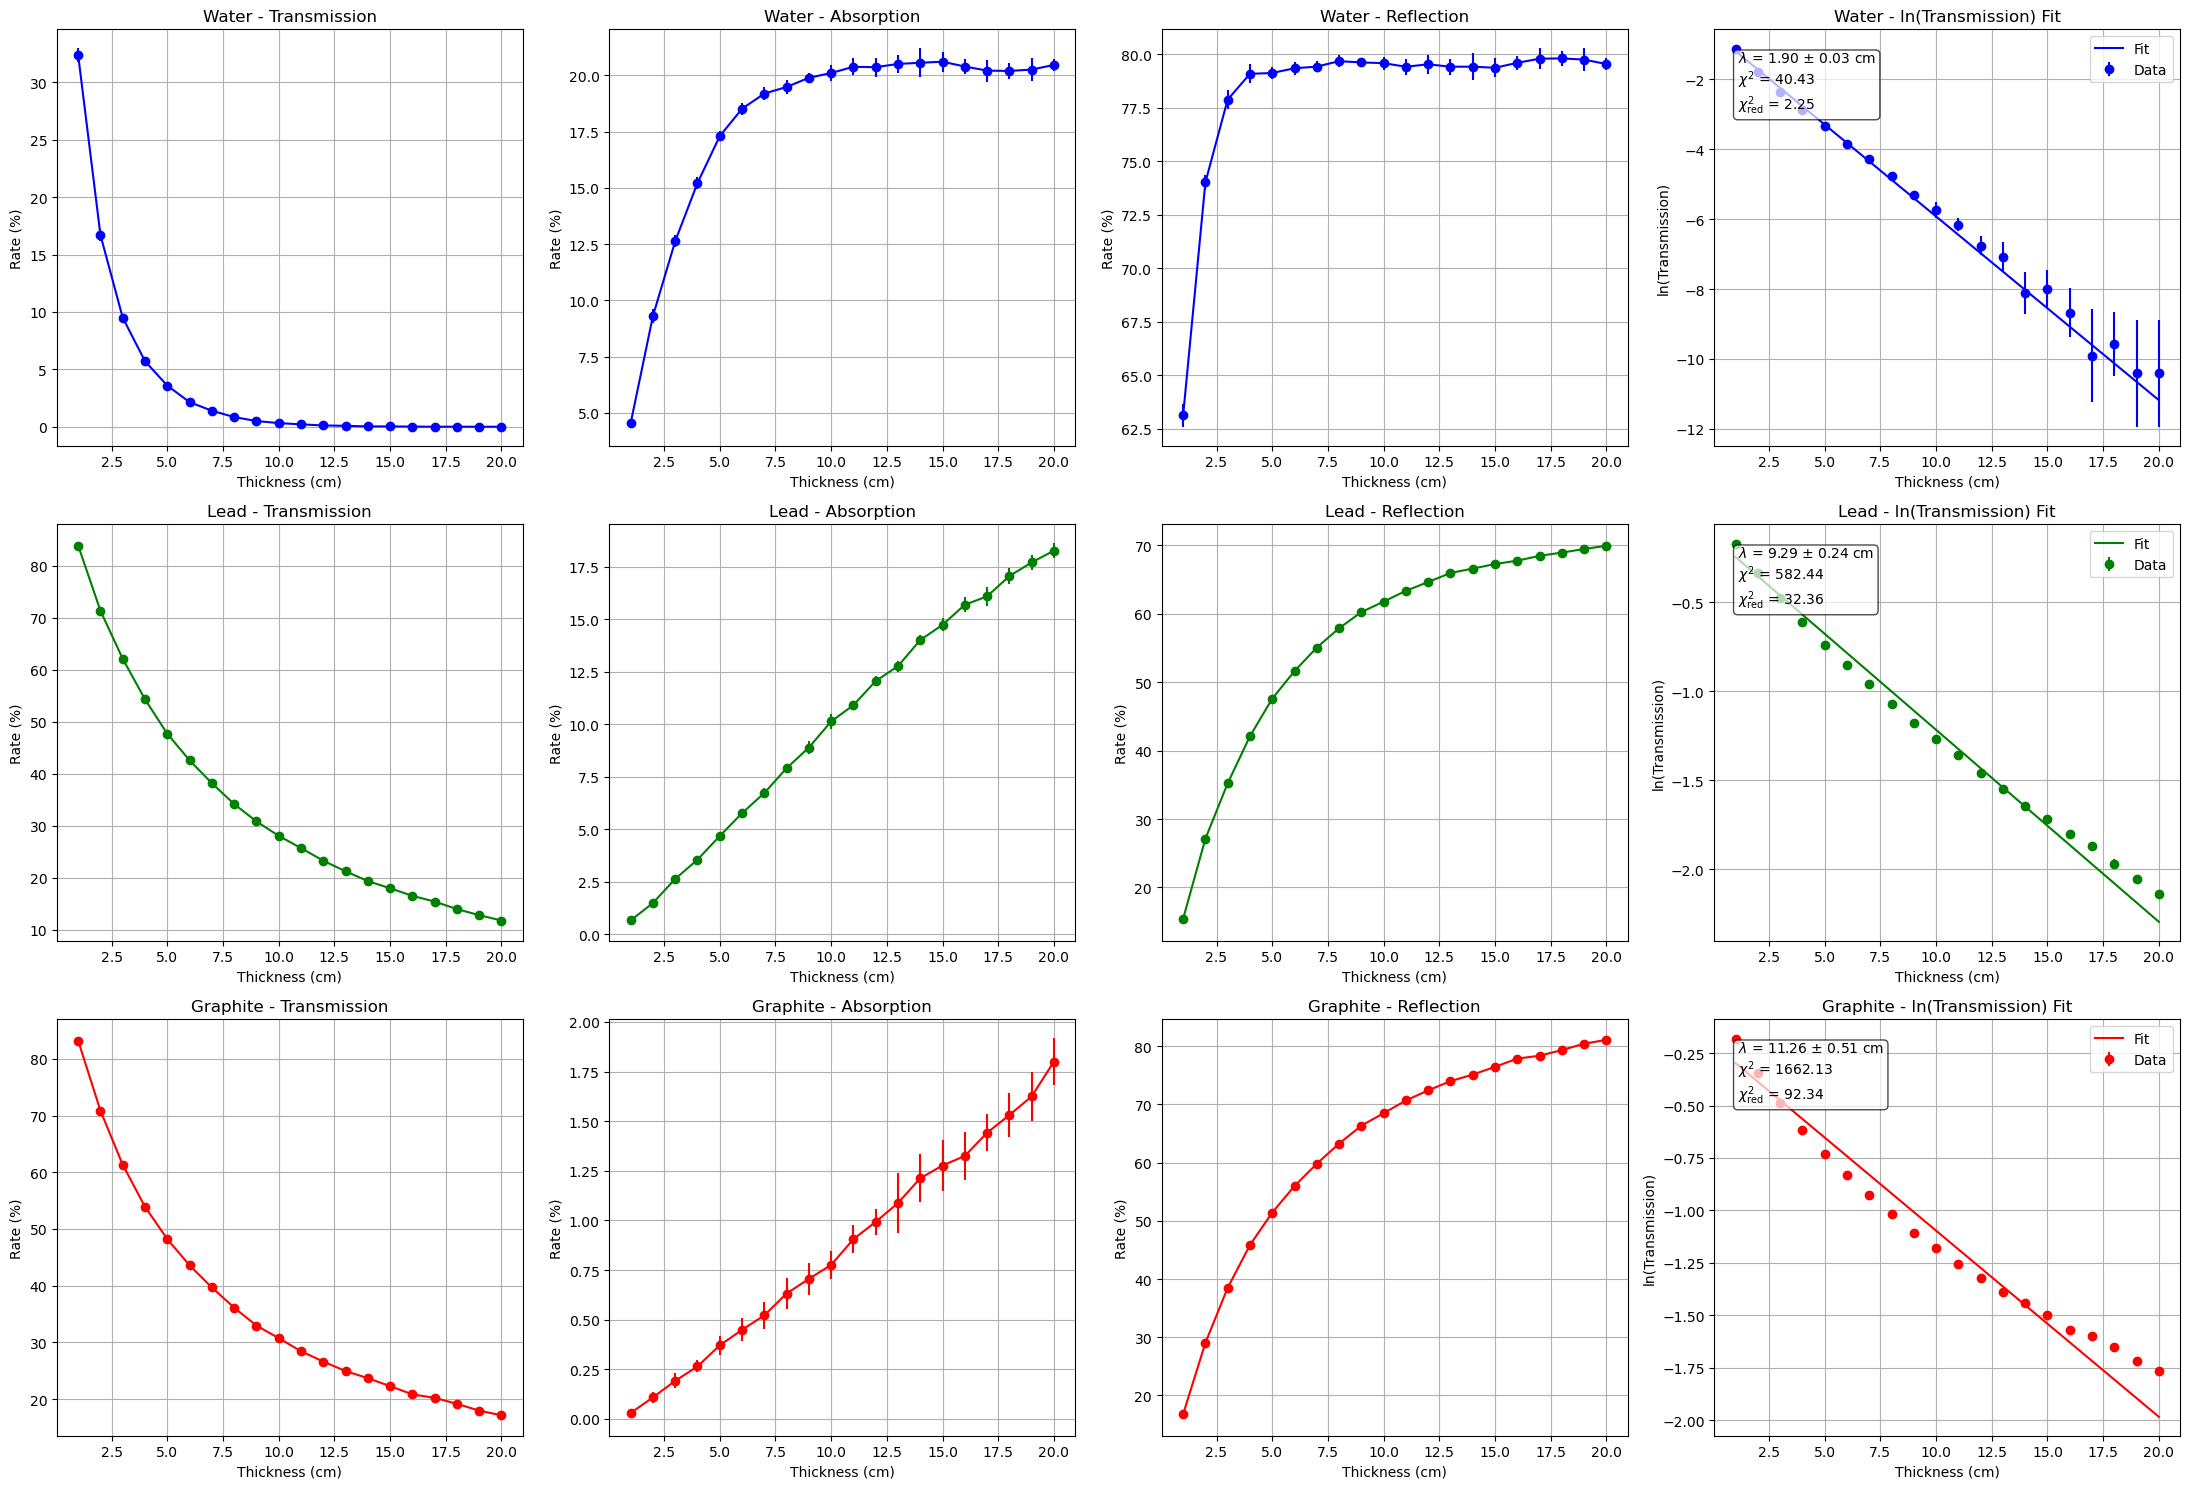


Fit Results Summary:


,Material,λ (cm) ± Error,χ²,χ²_red
0,Water,1.90 ± 0.03,40.43,2.25
1,Lead,9.29 ± 0.24,582.44,32.36
2,Graphite,11.26 ± 0.51,1662.13,92.34


In [ ]:
# --- Plot Transmission, Absorption, Reflection + Attenuation Fit ---

def plot_attenuation_fits(transmission_data, absorption_data, reflection_data, thicknesses_cm):
    """
    Plots shielding behaviour and attenuation curve fits for each material.

    Parameters:
        transmission_data (dict): {material_name: (means%, stds%)}
        absorption_data   (dict): {material_name: (means%, stds%)}
        reflection_data   (dict): {material_name: (means%, stds%)}
        thicknesses_cm (array): slab thickness values [cm]
    """
    n_materials = len(transmission_data)
    fig, axs = plt.subplots(n_materials, 4, figsize=(22, 5 * n_materials))

    fit_results = []
    colors = ['blue', 'green', 'red']

    for idx, name in enumerate(transmission_data):
        color = colors[idx % len(colors)]
        row = axs[idx]  # Get subplot row

        # Get data
        trans_mean, trans_std = transmission_data[name]
        abs_mean, abs_std = absorption_data[name]
        refl_mean, refl_std = reflection_data[name]
        x = np.array(thicknesses_cm)

        # Plot 1: Transmission
        row[0].errorbar(x, trans_mean, yerr=trans_std, fmt='o-', color=color)
        row[0].set_title(f"{name} - Transmission")
        row[0].set_xlabel("Thickness (cm)")
        row[0].set_ylabel("Rate (%)")
        row[0].grid(True)

        # Plot 2: Absorption
        row[1].errorbar(x, abs_mean, yerr=abs_std, fmt='o-', color=color)
        row[1].set_title(f"{name} - Absorption")
        row[1].set_xlabel("Thickness (cm)")
        row[1].set_ylabel("Rate (%)")
        row[1].grid(True)

        # Plot 3: Reflection
        row[2].errorbar(x, refl_mean, yerr=refl_std, fmt='o-', color=color)
        row[2].set_title(f"{name} - Reflection")
        row[2].set_xlabel("Thickness (cm)")
        row[2].set_ylabel("Rate (%)")
        row[2].grid(True)

        # --- Log-Fit: ln(Transmission) = -x / λ + const ---
        T_frac = trans_mean / 100
        T_err = trans_std / 100
        valid = T_frac > 0  # Avoid log(0)

        L = x[valid]
        T = T_frac[valid]
        sigma_T = T_err[valid]
        log_T = np.log(T)
        log_T_err = sigma_T / T

        weights = 1 / log_T_err
        coeffs, cov = np.polyfit(L, log_T, deg=1, w=weights, cov=True)
        slope, intercept = coeffs
        slope_err = np.sqrt(cov[0][0])

        λ = -1 / slope
        λ_err = slope_err / (slope ** 2)

        # Goodness of fit
        log_T_pred = slope * L + intercept
        chi_squared = np.sum(((log_T - log_T_pred) / log_T_err) ** 2)
        dof = len(L) - 2
        chi_squared_reduced = chi_squared / dof

        # Plot 4: Fit of ln(T)
        L_fit = np.linspace(min(L), max(L), 200)
        log_T_fit = slope * L_fit + intercept

        row[3].errorbar(L, log_T, yerr=log_T_err, fmt='o', color=color, label='Data')
        row[3].plot(L_fit, log_T_fit, '-', color=color, label='Fit')
        row[3].set_title(f"{name} - ln(Transmission) Fit")
        row[3].set_xlabel("Thickness (cm)")
        row[3].set_ylabel("ln(Transmission)")
        row[3].legend()
        row[3].grid(True)

        # Annotate fit results
        textstr = '\n'.join((
            rf"$\lambda$ = {λ:.2f} ± {λ_err:.2f} cm",
            rf"$\chi^2$ = {chi_squared:.2f}",
            rf"$\chi^2_{{\mathrm{{red}}}}$ = {chi_squared_reduced:.2f}"
        ))
        row[3].text(0.05, 0.95, textstr, transform=row[3].transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

        # Store for summary table
        fit_results.append({
            "Material": name,
            "λ (cm) ± Error": f"{λ:.2f} ± {λ_err:.2f}",
            "χ²": f"{chi_squared:.2f}",
            "χ²_red": f"{chi_squared_reduced:.2f}"
        })

    plt.tight_layout()
    plt.show()

    # Display summary table of fit results
    df = pd.DataFrame(fit_results)
    print("\nFit Results Summary:")
    display(df)


# --- Run the Fit Plotting ---
plot_attenuation_fits(transmission_data, absorption_data, reflection_data, thickness_range_cm)


## Two-Slab Neutron Shielding Using the Woodcock (Delta-Tracking) Method

This section implements a Monte Carlo simulation for neutron transport through two adjacent slabs using the **Woodcock delta-tracking method**, a technique particularly effective for heterogeneous geometries with varying cross-sections.

### Method Overview

In conventional tracking, each boundary between materials requires explicit geometric checks. Delta-tracking bypasses this by simulating all particle interactions with a **fictitious cross-section** equal to the maximum total interaction rate across all regions. The method proceeds as follows:

- A **step length** is sampled using the smallest mean free path (MFP), ensuring consistency regardless of region.
- Each step is either a **real interaction** (scattering or absorption) or a **fictitious interaction**, determined by a rejection probability:

$$
\mu = \frac{\text{MFP}_{\min}}{\text{MFP}_{\max}}
$$

- If a fictitious event occurs, the neutron continues in the same direction without interacting.

### Simulation Procedure

- Neutrons are initially launched in the $+z$ direction and propagated through a slab of thickness $L = L_1 + L_2$.
- During each step, the neutron's position determines whether it resides in **slab 1** or **slab 2**.
- The probabilities of **absorption**, **reflection** (escape through the entry face), or **transmission** (escape through the far side) are recorded.
- Cosine scattering angles are resampled for real events, but preserved across fictitious ones.

### Output and Physical Relevance

The function returns the **mean** and **standard deviation** (in %) for:
- **Transmitted** neutrons,
- **Absorbed** neutrons,
- **Reflected** neutrons,

averaged over multiple repetitions of the simulation.

This method is especially well-suited for **composite shielding systems** (e.g., lead–water layers) and reduces computational complexity while maintaining physical accuracy, even in highly non-uniform geometries.


In [ ]:
# --- Two-Slab Neutron Shielding with Woodcock Method ---

def Two_slab_shielding_with_woodcock(n, absorb_prob_slab1, length_slab1, MFP_slab1,
                                     absorb_prob_slab2, length_slab2, MFP_slab2, repeats):
    """
    Simulates neutron transport through two slabs using the Woodcock (delta-tracking) method.

    Parameters:
        n (int): number of neutrons per repeat
        absorb_prob_slab1/2: absorption probabilities for each slab
        length_slab1/2: slab thicknesses [cm]
        MFP_slab1/2: mean free path in each slab [cm]
        repeats (int): number of trials to average results

    Returns:
        means: [transmitted%, absorbed%, reflected%]
        stds:  corresponding standard deviations
    """
    transmitted = np.zeros(repeats)
    absorbed = np.zeros(repeats)
    reflected = np.zeros(repeats)

    length = length_slab1 + length_slab2
    MFP_smaller = min(MFP_slab1, MFP_slab2)
    MFP_max = max(MFP_slab1, MFP_slab2)
    mew = MFP_smaller / MFP_max  # fictitious rejection threshold

    for i in tnrange(repeats, desc="progress"):
        # Initial neutron positions (step along z-axis)
        z = Exponential_distribution(MFP_slab1, n)
        cos = np.full(n, 1.0)  # All neutrons move in +z initially
        absorb = np.random.uniform(size=n)
        fictional_prob = np.random.uniform(size=n)
        fiction = fictional_prob > mew  # True = fictitious interaction

        # Resample fictitious path lengths
        z[fiction] = Exponential_distribution(MFP_smaller, np.sum(fiction))

        neutrons = {
            'z': z,
            'cos': cos,
            'absorb': absorb,
            'fictional_prob': fictional_prob,
            'fiction': fiction
        }

        # CASE 1: Slab 1 has higher MFP than Slab 2
        if MFP_slab1 > MFP_slab2:
            while len(neutrons['z']) > 0:
                reflected[i] += np.count_nonzero(neutrons['z'] < 0)
                transmitted[i] += np.count_nonzero(neutrons['z'] > length)

                in_slab1 = (neutrons['z'] > 0) & (neutrons['z'] < length_slab1)
                in_slab2 = (neutrons['z'] >= length_slab1) & (neutrons['z'] < length)

                # Absorptions only count for real collisions
                absorbed[i] += np.count_nonzero((neutrons['absorb'][in_slab1] < absorb_prob_slab1) & (~neutrons['fiction'][in_slab1]))
                absorbed[i] += np.count_nonzero((neutrons['absorb'][in_slab2] < absorb_prob_slab2))

                keep_mask = (
                    ((neutrons['absorb'] > absorb_prob_slab1) & in_slab1 & ~neutrons['fiction']) |
                    ((neutrons['absorb'] > absorb_prob_slab2) & in_slab2) |
                    (in_slab1 & neutrons['fiction'])
                )

                # Filter and update all properties
                for key in neutrons:
                    neutrons[key] = neutrons[key][keep_mask]

                neutrons['fictional_prob'] = np.random.uniform(size=len(neutrons['z']))
                neutrons['absorb'] = np.random.uniform(size=len(neutrons['z']))
                neutrons['fiction'] = (neutrons['fictional_prob'] > mew) & (neutrons['z'] < length_slab1)

                # Resample angles
                cos = np.random.uniform(-1, 1, size=len(neutrons['z']))
                cos[neutrons['fiction']] = neutrons['cos'][neutrons['fiction']]
                neutrons['cos'] = cos

                radius = Exponential_distribution(MFP_smaller, len(neutrons['z']))
                neutrons['z'] += radius * neutrons['cos']

        # CASE 2: Slab 2 has higher MFP than Slab 1
        else:
            while len(neutrons['z']) > 0:
                reflected[i] += np.count_nonzero(neutrons['z'] < 0)
                transmitted[i] += np.count_nonzero(neutrons['z'] > length)

                in_slab1 = (neutrons['z'] > 0) & (neutrons['z'] < length_slab1)
                in_slab2 = (neutrons['z'] >= length_slab1) & (neutrons['z'] < length)

                absorbed[i] += np.count_nonzero((neutrons['absorb'][in_slab1] < absorb_prob_slab1))
                absorbed[i] += np.count_nonzero((neutrons['absorb'][in_slab2] < absorb_prob_slab2) & (~neutrons['fiction'][in_slab2]))

                keep_mask = (
                    ((neutrons['absorb'] > absorb_prob_slab1) & in_slab1) |
                    ((neutrons['absorb'] > absorb_prob_slab2) & in_slab2 & ~neutrons['fiction']) |
                    (in_slab2 & neutrons['fiction'])
                )

                for key in neutrons:
                    neutrons[key] = neutrons[key][keep_mask]

                neutrons['fictional_prob'] = np.random.uniform(size=len(neutrons['z']))
                neutrons['absorb'] = np.random.uniform(size=len(neutrons['z']))
                neutrons['fiction'] = (neutrons['fictional_prob'] > mew) & (neutrons['z'] > length_slab1)

                cos = np.random.uniform(-1, 1, size=len(neutrons['z']))
                cos[neutrons['fiction']] = neutrons['cos'][neutrons['fiction']]
                neutrons['cos'] = cos

                radius = Exponential_distribution(MFP_smaller, len(neutrons['z']))
                neutrons['z'] += radius * neutrons['cos']

    # Convert to percentages
    means = [
        np.mean(transmitted) / n * 100,
        np.mean(absorbed) / n * 100,
        np.mean(reflected) / n * 100
    ]

    stds = [
        np.std(transmitted) / n * 100,
        np.std(absorbed) / n * 100,
        np.std(reflected) / n * 100
    ]

    return means, stds

## Two-Slab Shielding Visualisation and Comparison

To analyse the effect of **layered shielding**, this section simulates neutron transport through **two adjacent materials**, using the **Woodcock (delta-tracking) method**.

### Simulation Setup
For each material pair:
- Each slab is set to a thickness of **5 cm**, resulting in a total shield depth of **10 cm**.
- **10,000 neutrons** are simulated for each pair, repeated **10 times** to estimate statistical uncertainties.
- The neutron’s fate—**transmitted**, **absorbed**, or **reflected**—is recorded and averaged.

### Materials Simulated
Three material combinations are tested:
- **Water + Lead**,
- **Lead + Graphite**,
- **Graphite + Water**.

Each pair is simulated in the listed order, reflecting realistic shielding scenarios where high-scattering moderators (e.g. water or graphite) are layered with high-absorption materials (e.g. lead).

### Output Format
- **Pie Charts**: Each chart visualises the proportion of transmitted, absorbed, and reflected neutrons. Error values (± standard deviation) are shown below each chart.
- **Results Table**: A summary table reports the percentage and uncertainty for each interaction type per material pair.

This side-by-side visualisation provides intuitive insights into how the **ordering of materials** affects neutron attenuation. For instance, placing lead before graphite may result in higher absorption and lower transmission than the reverse configuration.
efficiently.


progress:   0%|          | 0/10 [00:00<?, ?it/s]

progress:   0%|          | 0/10 [00:00<?, ?it/s]

progress:   0%|          | 0/10 [00:00<?, ?it/s]

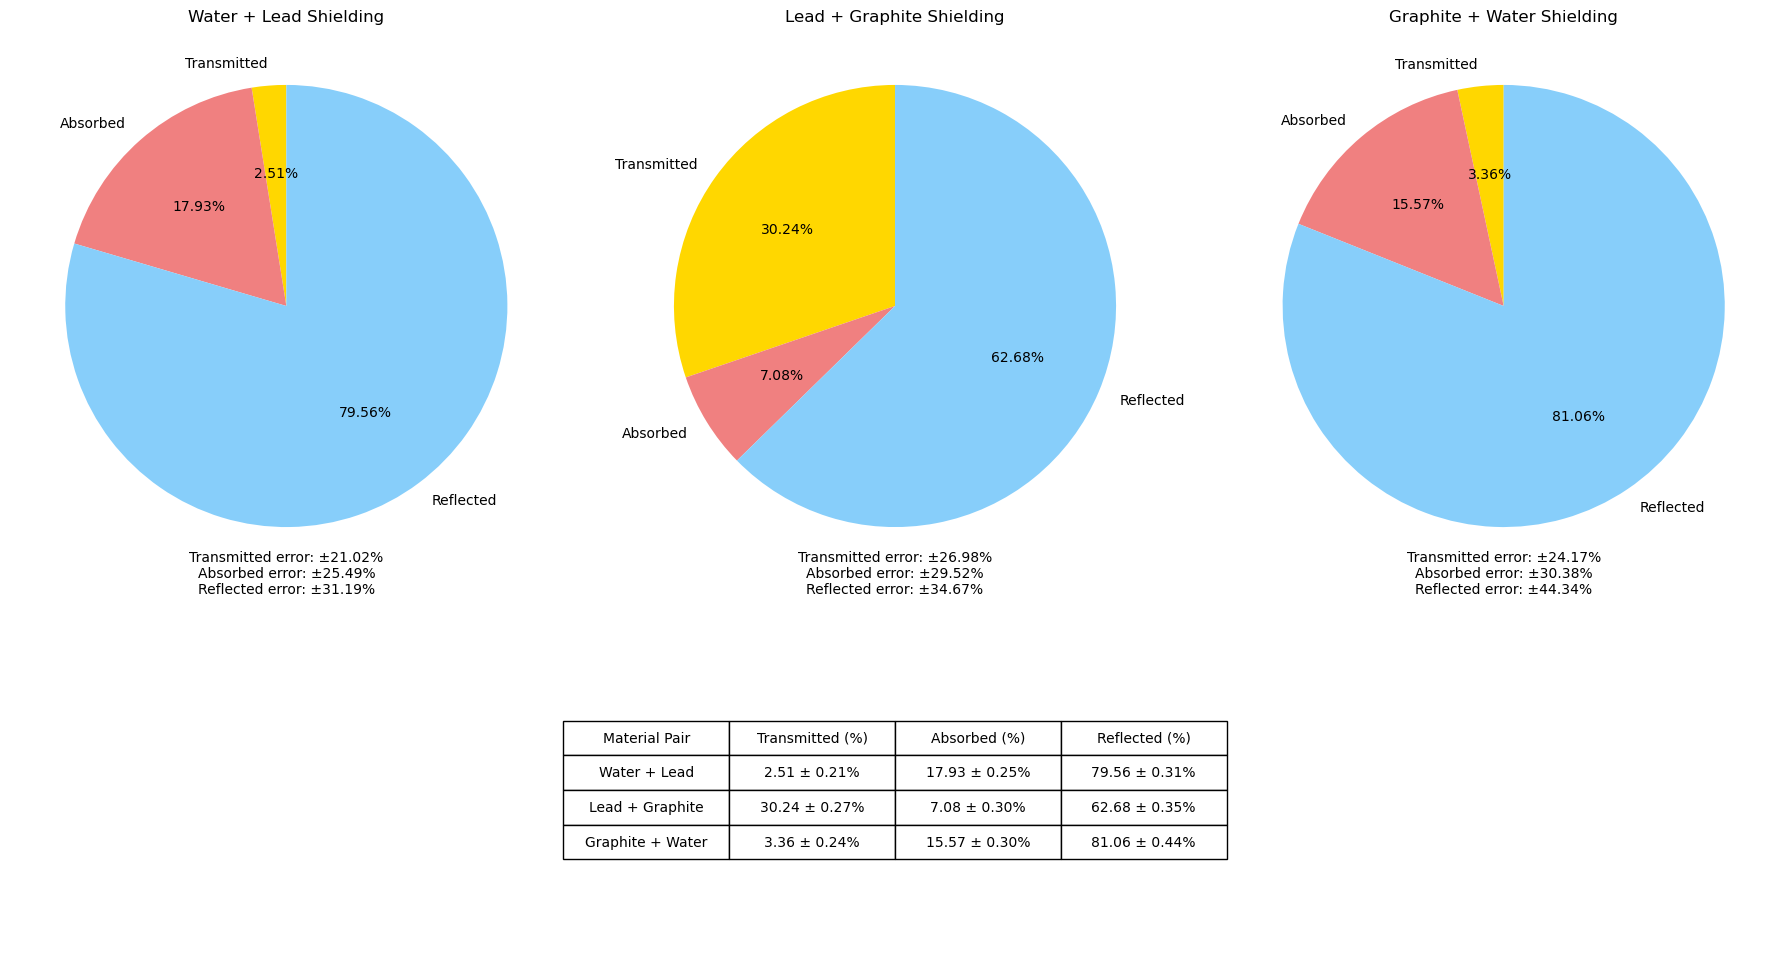

In [ ]:
def plot_two_slab_results(material_pairs):
    length_slab1 = 5
    length_slab2 = 5
    repeats = 10
    neutron_number = 10000
    labels = ['Transmitted', 'Absorbed', 'Reflected']
    colors = ['gold', 'lightcoral', 'lightskyblue']

    results = []
    for mat1, mat2 in material_pairs:
        mean, std = Two_slab_shielding_with_woodcock(
            neutron_number,
            mat1.Absorption_prob, length_slab1, mat1.MFP_Total,
            mat2.Absorption_prob, length_slab2, mat2.MFP_Total,
            repeats
        )
        results.append(((mat1.name, mat2.name), mean, std))

    # Prepare the table data
    combined_data = {
        "Material Pair": [f"{mat1} + {mat2}" for mat1, mat2 in [((mat1.name, mat2.name)) for mat1, mat2 in material_pairs]],
        "Transmitted (%)": [f"{mean[0]:.2f} ± {std[0]:.2f}%" for _, mean, std in results],
        "Absorbed (%)": [f"{mean[1]:.2f} ± {std[1]:.2f}%" for _, mean, std in results],
        "Reflected (%)": [f"{mean[2]:.2f} ± {std[2]:.2f}%" for _, mean, std in results],
    }

    df = pd.DataFrame(combined_data)

    # Create figure with subplots for pie charts and table
    fig, axs = plt.subplots(2, 3, figsize=(18, 10), gridspec_kw={'height_ratios': [2, 1]})

    # Pie chart for each material pair
    def plot_pie_chart(ax, mean, std, material_pair):
        ax.pie(mean, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
        ax.set_title(f'{material_pair[0]} + {material_pair[1]} Shielding')
        text = '\n'.join(f"{label} error: ±{std[i]*100:.2f}%" for i, label in enumerate(labels))
        ax.text(0, -1.3, text, ha='center', fontsize=10)

    for i, ((mat1, mat2), mean, std) in enumerate(results):
        plot_pie_chart(axs[0, i], mean, std, (mat1, mat2))

    # Create table below the pie charts
    axs[1, 0].axis('off')
    axs[1, 1].axis('off')
    axs[1, 2].axis('off')
    table_ax = axs[1, 1]

    table_ax.axis('off')
    mpl_table = table_ax.table(cellText=df.values, colLabels=df.columns,
                               cellLoc='center', loc='center')
    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(10)
    mpl_table.scale(1.2, 1.5)

    plt.tight_layout()
    plt.show()

material_pairs = [(Water, Lead), (Lead, Graphite), (Graphite, Water)]
plot_two_slab_results(material_pairs)

## Energy-Dependent Shielding Material Definitions

To simulate neutron transport across different energy regimes, each material — **Water**, **Lead**, and **Graphite** — is defined separately for:

- **Thermal neutrons** ($E \approx 0.025~\text{eV}$)
- **Epithermal neutrons** ($0.1~\text{eV} \lesssim E \lesssim 100~\text{keV}$)
- **Fast neutrons** ($E \gtrsim 0.1~\text{MeV}$)

Each material instance includes:

- Microscopic absorption cross-section $\sigma_a$ (barns),
- Microscopic scattering cross-section $\sigma_s$ (barns),
- Density $\rho$ (g/cm³),
- Molar mass $M$ (g/mol)

These parameters are used to calculate the number density $n$ and mean free paths:

$$
n = \frac{\rho N_A}{M}
$$

$$
\lambda_{\text{abs}} = \frac{1}{n \sigma_a}, \quad
\lambda_{\text{scat}} = \frac{1}{n \sigma_s}, \quad
\lambda_{\text{total}} = \frac{1}{n (\sigma_a + \sigma_s)}
$$

### Cross-Section Summary (Absorption / Scattering in Barns)

| Material   | Thermal           | Epithermal        | Fast             |
|------------|-------------------|-------------------|------------------|
| **Water**  | 0.6652 / 103.0    | 0.1 / 20.0        | 0.01 / 3.0       |
| **Lead**   | 0.158 / 11.221    | 0.12 / 8.0        | 0.4 / 7.0        |
| **Graphite** | 0.0045 / 4.74   | 0.002 / 3.0       | 0.001 / 2.0      |

(All cross-sections are in barns, where $1~\text{barn} = 10^{-24}~\text{cm}^2$)

---

This structure enables the Monte Carlo model to adapt to energy-dependent neutron interactions — a critical capability when simulating realistic shielding environments like reactors or accelerator facilities.



In [ ]:
# --- Water ---
Water_Thermal     = shield(0.6652, 103.0, 1, 18.0153, "Water_Thermal")
Water_Epithermal  = shield(0.1,    20.0,  1, 18.0153, "Water_Epithermal")
Water_Fast        = shield(0.01,   3.0,   1, 18.0153, "Water_Fast")

# --- Lead ---
Lead_Thermal      = shield(0.158,  11.221, 11.35, 207.2,   "Lead_Thermal")
Lead_Epithermal   = shield(0.12,   8.0,    11.35, 207.2,   "Lead_Epithermal")
Lead_Fast         = shield(0.4,    7.0,    11.35, 207.2,   "Lead_Fast")

# --- Graphite ---
Graphite_Thermal    = shield(0.0045, 4.74, 1.67, 12.011, "Graphite_Thermal")
Graphite_Epithermal = shield(0.002,  3.0,  1.67, 12.011, "Graphite_Epithermal")
Graphite_Fast       = shield(0.001,  2.0,  1.67, 12.011, "Graphite_Fast")

## Energy-Dependent Shielding Performance for a Single Material

To understand how a material attenuates neutrons of different energies, we simulate its shielding performance across three energy regimes:

- **Thermal neutrons** ($E \approx 0.025~\text{eV}$)
- **Epithermal neutrons** ($10^{-1}~\text{eV} \lesssim E \lesssim 10^{5}~\text{eV}$)
- **Fast neutrons** ($E \gtrsim 0.1~\text{MeV}$)

### Simulation Procedure

For each energy type:
- A `shield` object is instantiated using appropriate cross-section values.
- A **single-slab Monte Carlo simulation** is run for 10,000 neutrons repeated over 10 trials.
- At each step, the fate of each neutron (transmission, absorption, reflection) is recorded.

### Output Format

- **Top Row**: Pie charts showing the proportion of transmitted, absorbed, and reflected neutrons.
- **Bottom Row**: Summary table reporting the average percentage and standard deviation of each outcome.

Each pie chart includes the statistical uncertainty associated with each category:

$$
\text{Error} = \frac{\sigma}{n} \times 100\%
$$

This analysis illustrates the **energy dependence of neutron interaction probabilities**, highlighting how a single material's shielding efficiency can vary significantly across the energy spectrum.



In [ ]:
# --- Plot Shielding Performance by Neutron Energy for One Material ---

def plot_material_shielding(material_shields):
    """
    Visualises how shielding changes across neutron energy types
    (Thermal, Epithermal, Fast) for a single material.

    Parameters:
        material_shields (list of shield objects):
            Ordered as [Thermal, Epithermal, Fast] for one material.
    """
    length = 10  # Slab thickness (cm)
    repeats = 10
    n = 10000  # Number of neutrons per trial

    results = []
    for sh in material_shields:
        means, stds = Single_slab_shielding(n, sh.Absorption_prob, length, sh.MFP_Total, repeats)
        results.append((sh.name, means, stds))

    fig, axs = plt.subplots(2, 3, figsize=(18, 10), gridspec_kw={'height_ratios': [2, 1]})
    labels = ['Transmitted', 'Absorbed', 'Reflected']
    colors = ['gold', 'lightcoral', 'lightskyblue']

    # --- Pie Chart Helper ---
    def plot_pie(ax, ratios, stds, title):
        ax.pie(ratios, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
        ax.set_title(title)
        error_text = '\n'.join(f"{label} error: ±{std * 100:.2f}%" for label, std in zip(labels, stds))
        ax.text(0, -1.3, error_text, ha='center', fontsize=9)

    # --- Upper Row: Pie Charts ---
    for i, (name, means, stds) in enumerate(results):
        plot_pie(axs[0, i], means, stds, name)

    # --- Lower Row: Table with Summary ---
    for ax in axs[1]:
        ax.axis('off')

    def fmt(val, err):
        return f"{val * 100:.2f} ± {err * 100:.2f}"

    data = {
        "Energy": [],
        "Transmitted (%)": [],
        "Absorbed (%)": [],
        "Reflected (%)": []
    }

    for name, means, stds in results:
        energy_label = name.split("_")[-1]  # e.g. 'Thermal'
        data["Energy"].append(energy_label)
        data["Transmitted (%)"].append(fmt(means[0], stds[0]))
        data["Absorbed (%)"].append(fmt(means[1], stds[1]))
        data["Reflected (%)"].append(fmt(means[2], stds[2]))

    df = pd.DataFrame(data)

    # Insert table in the middle-bottom subplot
    table_ax = axs[1, 1]
    table_ax.axis('off')
    mpl_table = table_ax.table(cellText=df.values, colLabels=df.columns,
                               cellLoc='center', loc='center')
    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(10)
    mpl_table.scale(1.3, 1.5)

    plt.tight_layout()
    plt.show()



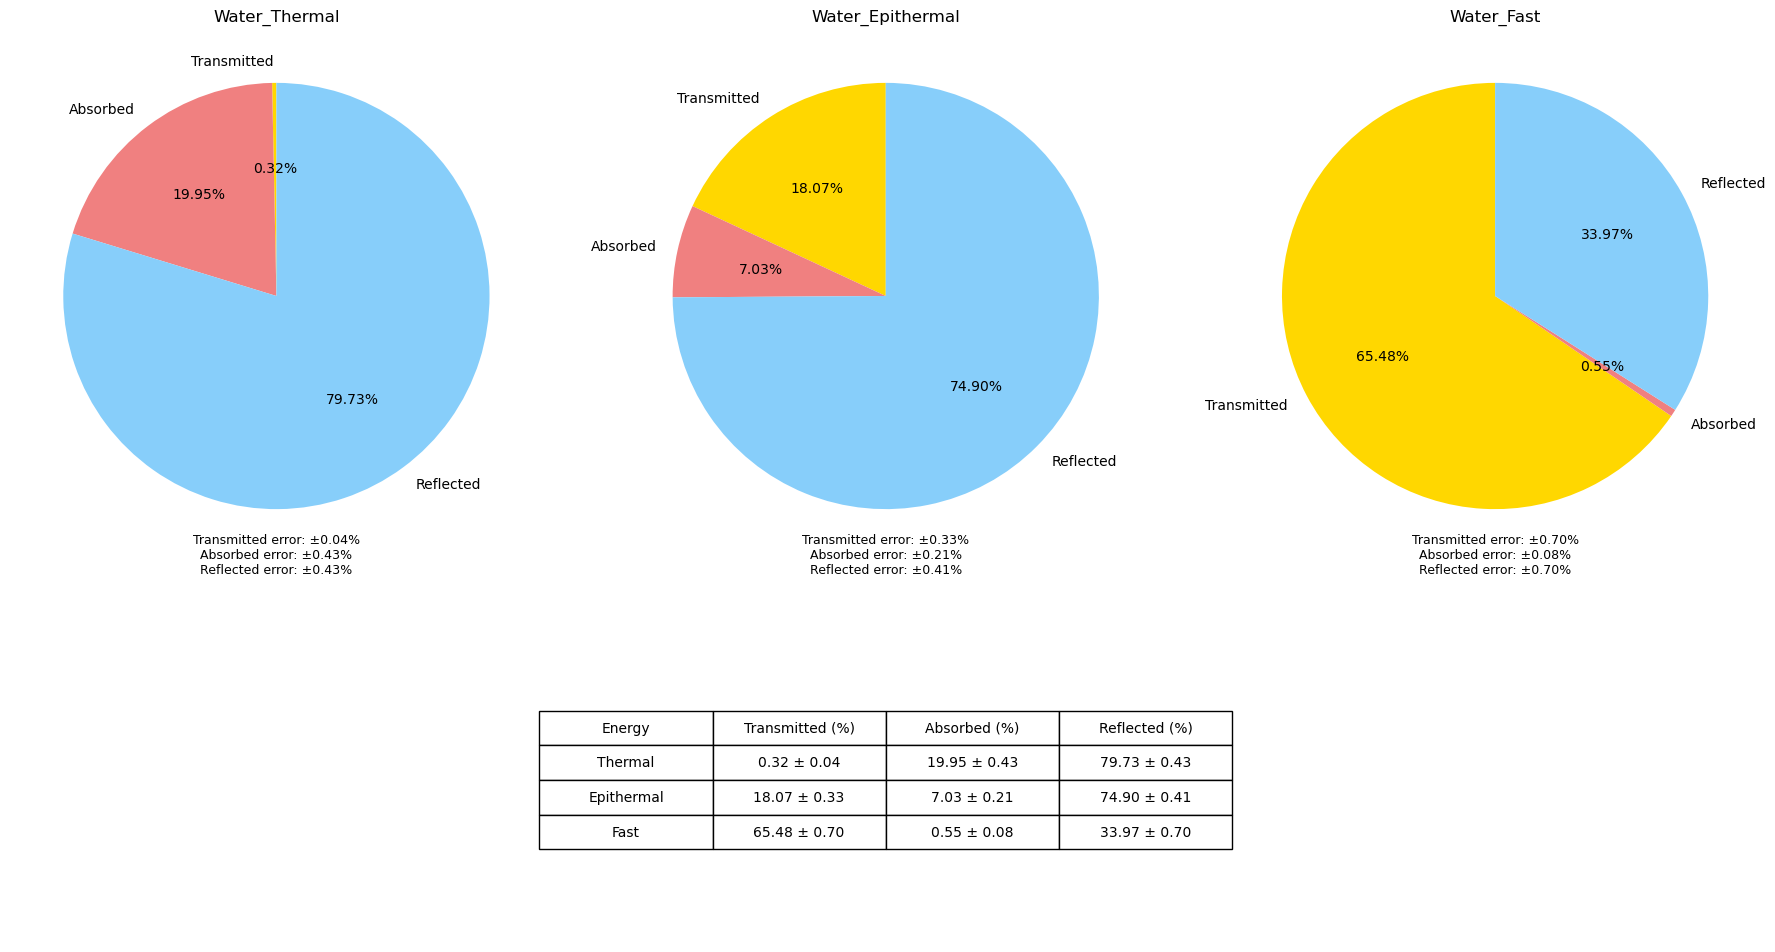

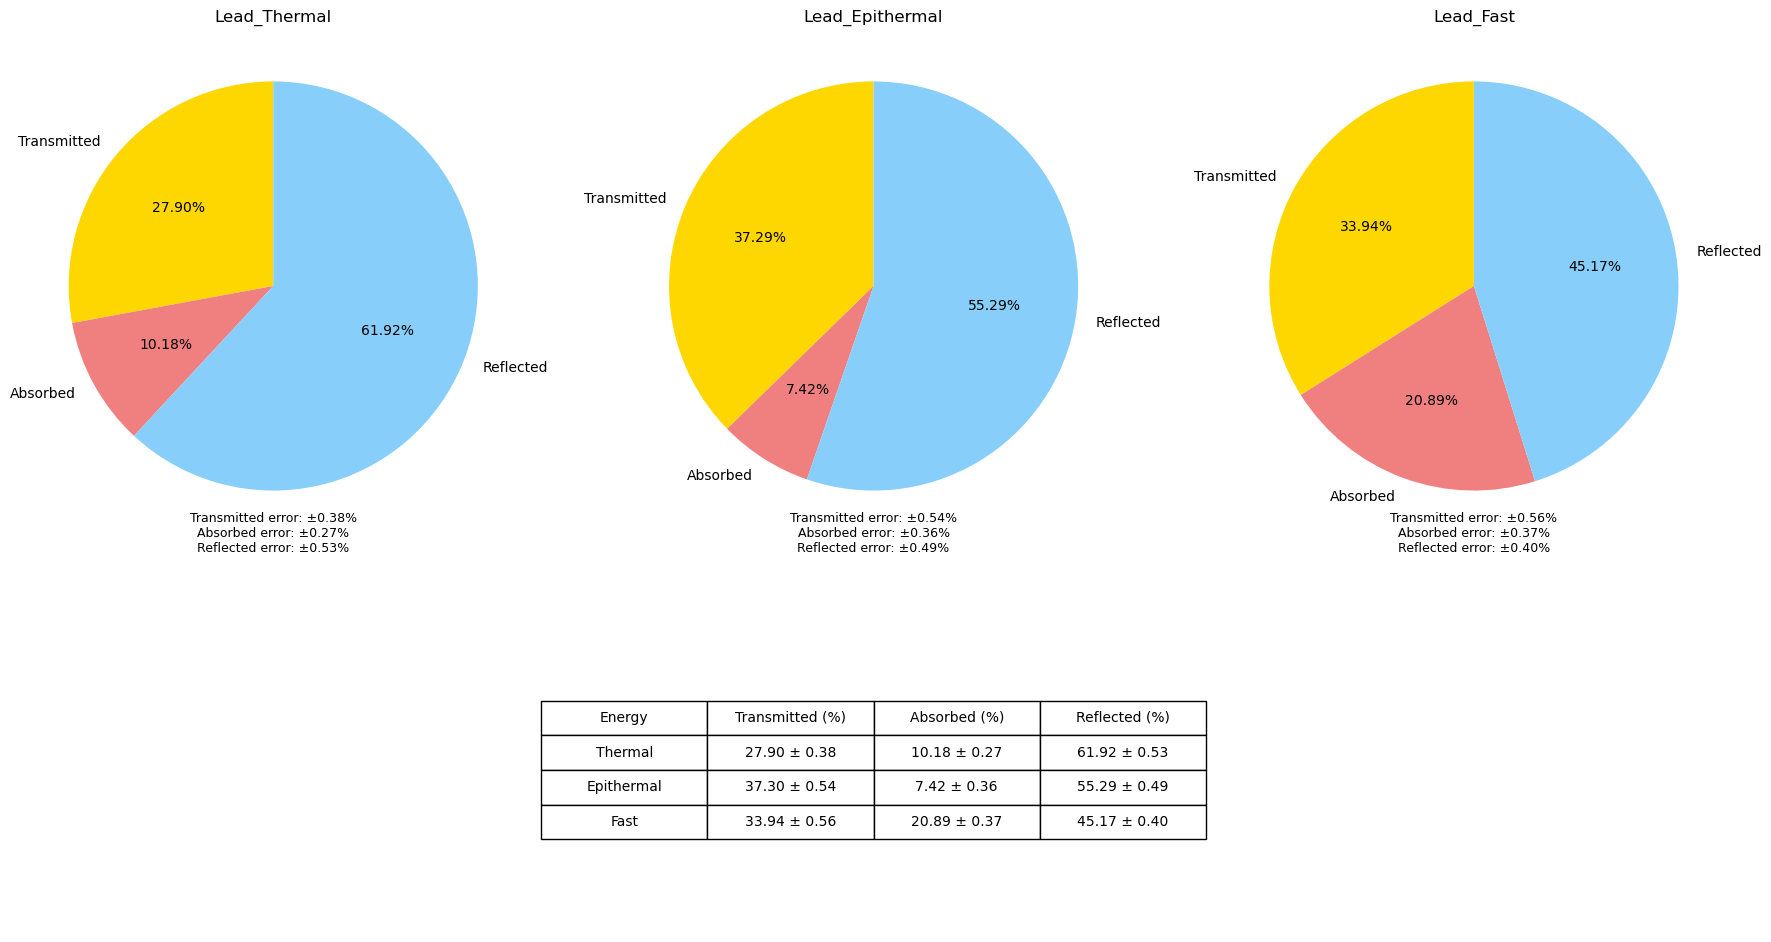

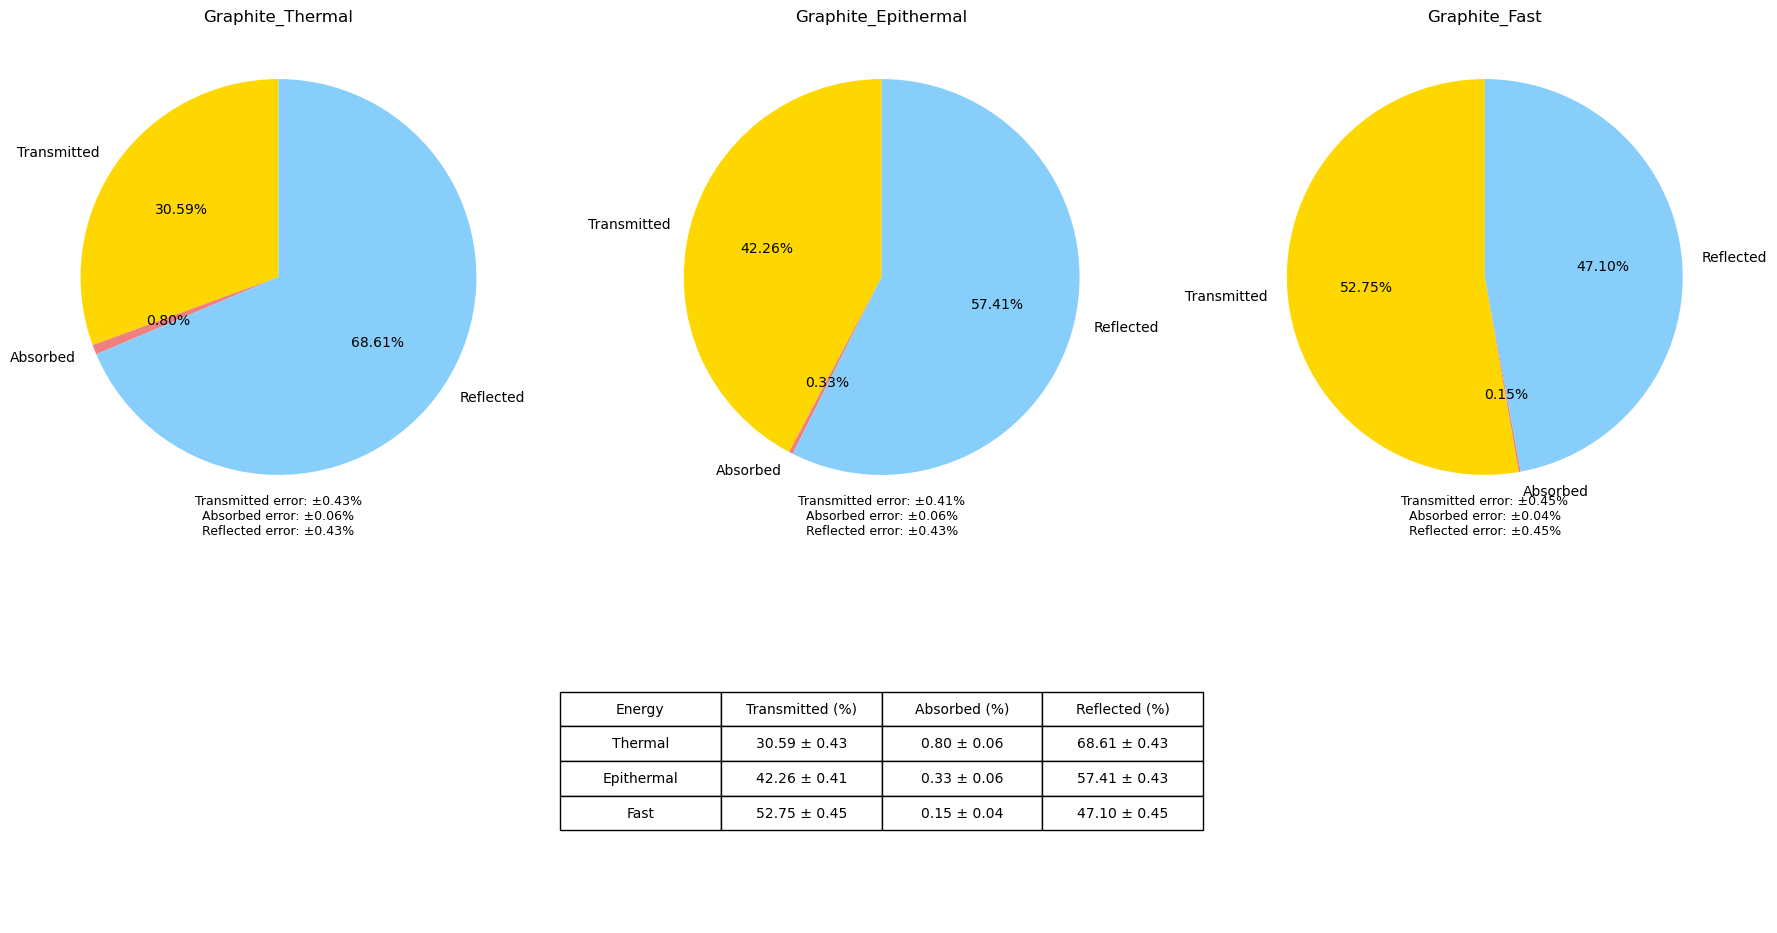

In [ ]:
plot_material_shielding([Water_Thermal, Water_Epithermal, Water_Fast])
plot_material_shielding([Lead_Thermal, Lead_Epithermal, Lead_Fast])
plot_material_shielding([Graphite_Thermal, Graphite_Epithermal, Graphite_Fast])

## Shielding Simulation with Mixed Neutron Energy Spectrum

To approximate realistic neutron fields, this simulation splits a population of neutrons equally into **thermal**, **epithermal**, and **fast** groups. The shielding behaviour of a single material is then evaluated against this mixed energy spectrum.

### Methodology

- The total neutron count \( n \) is divided equally among the three energy regimes.
- For each energy group, neutrons are propagated using:
  - An **exponentially distributed step size** based on the group’s total mean free path,
  - A **random direction** sampled uniformly in \( \cos(\theta) \in [-1, 1] \).
- At each step, a neutron can:
  - **Transmit** (exit beyond the slab),
  - **Reflect** (re-enter from the incident side),
  - **Be absorbed**, based on the material’s absorption probability.

Each group is treated independently, and their contributions are accumulated to yield total shielding performance.

### Output

The function returns the overall **transmitted**, **absorbed**, and **reflected fractions** (averaged over all groups and trials), along with their associated **standard deviations**:

- Mean values:
  $$
  \text{Rate} = \frac{1}{3n} \sum \text{(event count across all energies)}
  $$
- Standard deviation:
  $$
  \sigma = \frac{\text{Std across trials}}{3n}
  $$

This enables benchmarking a material’s effectiveness under a **broad-spectrum neutron exposure**, rather than just monoenergetic assumptions.


In [ ]:
def Single_slab_shielding_energy_split(n, shields, length, repeats, disable=True):
    """
    Simulates slab shielding using equal numbers of thermal, epithermal, and fast neutrons.

    Parameters:
        n (int): total number of neutrons (will be split equally among 3 energy types)
        shields (list of 3 shield objects): [Thermal, Epithermal, Fast]
        length (float): slab thickness in cm
        repeats (int): number of Monte Carlo trials
        disable (bool): whether to disable tqdm progress bar

    Returns:
        means (list): [transmitted%, absorbed%, reflected%]
        stds  (list): standard deviations for each percentage
    """
    transmitted = np.zeros(repeats)
    absorbed = np.zeros(repeats)
    reflected = np.zeros(repeats)

    n_per_type = n // 3  # Equal split

    for i in tnrange(repeats, desc="progress", disable=disable):
        for sh in shields:
            neutrons = Exponential_distribution(sh.MFP_Total, n_per_type)
            absorb = np.random.uniform(size=n_per_type)

            while len(neutrons) > 0:
                transmitted[i] += np.count_nonzero(neutrons > length)
                reflected[i] += np.count_nonzero(neutrons < 0)

                in_slab = (neutrons > 0) & (neutrons < length)
                absorbed[i] += np.count_nonzero(absorb[in_slab] < sh.Absorption_prob)

                keep_mask = ((absorb > sh.Absorption_prob) & in_slab)
                neutrons = neutrons[keep_mask]

                radius = Exponential_distribution(sh.MFP_Total, len(neutrons))
                cos = np.random.uniform(-1, 1, size=len(neutrons))
                neutrons += radius * cos
                absorb = np.random.uniform(size=len(neutrons))

    total_neutrons = n_per_type * 3
    means = [
        np.mean(transmitted) / total_neutrons,
        np.mean(absorbed) / total_neutrons,
        np.mean(reflected) / total_neutrons
    ]
    stds = [
        np.std(transmitted) / total_neutrons,
        np.std(absorbed) / total_neutrons,
        np.std(reflected) / total_neutrons
    ]
    return means, stds


## Shielding Performance Under Mixed Neutron Energy Spectrum

This analysis evaluates the shielding behaviour of **Water**, **Lead**, and **Graphite** when exposed to an equal number of thermal, epithermal, and fast neutrons. The simulation uses the `Single_slab_shielding_energy_split()` function, which processes 3,000 neutrons of each energy type (total \( n = 9000 \)) for each material.

### Simulation Procedure

- **Neutron Energy Types**:
  - **Thermal**: \( E \approx 0.025 \ \text{eV} \)
  - **Epithermal**: \( 0.1 \ \text{eV} < E < 100 \ \text{keV} \)
  - **Fast**: \( E > 0.1 \ \text{MeV} \)
- For each material, the neutron fate is recorded as:
  - **Transmitted**: neutron exits the far side of the slab,
  - **Absorbed**: neutron is removed via capture,
  - **Reflected**: neutron exits the incident side.

Each neutron group is simulated with energy-dependent cross-sections, densities, and mean free paths.

### Results and Visualisation

- **Top Row**: Pie charts showing the average rates of transmission, absorption, and reflection for each material.
- **Bottom Row**: A summary table displaying the percentage values alongside their standard deviations:

$$
\text{Rate (\%)} = \frac{\text{Mean Count}}{n_\text{total}} \times 100, \quad
\sigma = \frac{\text{Standard Deviation}}{n_\text{total}} \times 100
$$

This setup allows comparison of shielding effectiveness across materials in realistic mixed-energy neutron environments, highlighting the influence of energy-dependent nuclear interactions.


In [ ]:
def plot_shielding_results():
    """
    Runs shielding simulations using equal numbers of thermal, epithermal, and fast neutrons
    for Water, Lead, and Graphite. Displays results as pie charts with standard deviations
    and a summary table.
    """
    length = 10
    repeats = 10
    neutron_number = 9000  # will be split 3 ways (3000 of each neutron type)

    # Define shield sets per material
    water_shields = [Water_Thermal, Water_Epithermal, Water_Fast]
    lead_shields = [Lead_Thermal, Lead_Epithermal, Lead_Fast]
    graphite_shields = [Graphite_Thermal, Graphite_Epithermal, Graphite_Fast]

    # Run simulations using updated function
    water_ratio = Single_slab_shielding_energy_split(neutron_number, water_shields, length, repeats, disable=False)
    lead_ratio = Single_slab_shielding_energy_split(neutron_number, lead_shields, length, repeats, disable=False)
    graphite_ratio = Single_slab_shielding_energy_split(neutron_number, graphite_shields, length, repeats, disable=False)

    labels = ['Transmitted', 'Absorbed', 'Reflected']
    colors = ['gold', 'lightcoral', 'lightskyblue']
    fig, axs = plt.subplots(2, 3, figsize=(18, 10), gridspec_kw={'height_ratios': [2, 1]})

    def plot_pie_chart(ax, ratios, stds, material_name):
        ax.pie(ratios, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
        ax.set_title(f'{material_name} Shielding')
        error_text = '\n'.join(f"{label} error: ±{std * 100:.2f}%" for label, std in zip(labels, stds))
        ax.text(0, -1.3, error_text, ha='center', fontsize=10)

    # Pie charts for each material
    plot_pie_chart(axs[0, 0], water_ratio[0], water_ratio[1], 'Water')
    plot_pie_chart(axs[0, 1], lead_ratio[0], lead_ratio[1], 'Lead')
    plot_pie_chart(axs[0, 2], graphite_ratio[0], graphite_ratio[1], 'Graphite')

    def combine(val, err):
        return f"{val * 100:.2f} ± {err * 100:.2f}"

    materials = ['Water', 'Lead', 'Graphite']
    combined_data = {
        "Material": materials,
        "Transmitted (%)": [
            combine(water_ratio[0][0], water_ratio[1][0]),
            combine(lead_ratio[0][0], lead_ratio[1][0]),
            combine(graphite_ratio[0][0], graphite_ratio[1][0])
        ],
        "Absorbed (%)": [
            combine(water_ratio[0][1], water_ratio[1][1]),
            combine(lead_ratio[0][1], lead_ratio[1][1]),
            combine(graphite_ratio[0][1], graphite_ratio[1][1])
        ],
        "Reflected (%)": [
            combine(water_ratio[0][2], water_ratio[1][2]),
            combine(lead_ratio[0][2], lead_ratio[1][2]),
            combine(graphite_ratio[0][2], graphite_ratio[1][2])
        ],
    }

    df = pd.DataFrame(combined_data)

    # Table rendering
    axs[1, 0].axis('off')
    axs[1, 1].axis('off')
    axs[1, 2].axis('off')
    table_ax = axs[1, 1]
    table_ax.axis('off')
    mpl_table = table_ax.table(cellText=df.values, colLabels=df.columns,
                               cellLoc='center', loc='center')
    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(10)
    mpl_table.scale(1.2, 1.5)

    plt.tight_layout()
    plt.show()


progress:   0%|          | 0/10 [00:00<?, ?it/s]

progress:   0%|          | 0/10 [00:00<?, ?it/s]

progress:   0%|          | 0/10 [00:00<?, ?it/s]

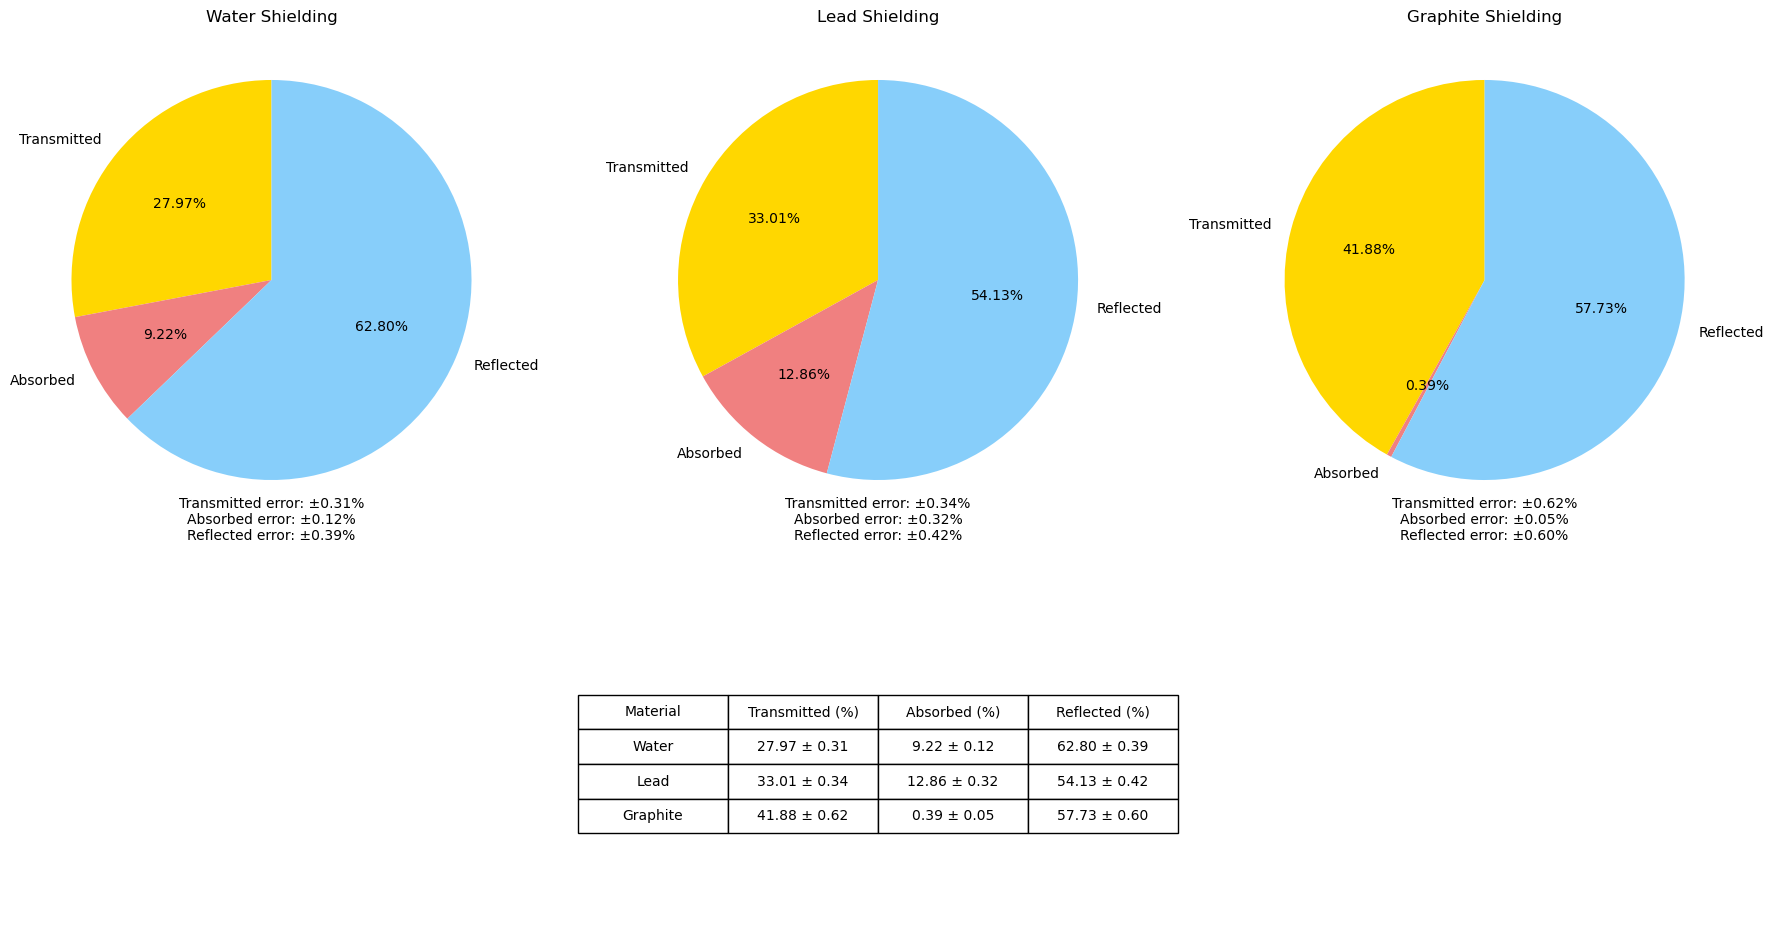

In [ ]:
plot_shielding_results()

## Conclusion

This project successfully applied **Monte Carlo techniques** to model neutron shielding in various materials under differing conditions. By simulating random walks, exponential path lengths, and isotropic scattering, we quantitatively assessed the shielding performance of **Water**, **Lead**, and **Graphite** against neutrons of thermal, epithermal, and fast energies.

### Key Outcomes

- **Verification of Random Sampling**: Preliminary visual checks in 1D, 2D, and 3D confirmed the statistical integrity of random number generation used for spatial and angular distributions.

- **Material Dependence**: The effectiveness of shielding was shown to strongly depend on both **material composition** and **neutron energy**. Water was effective in scattering thermal neutrons, Lead excelled in absorption across energies, and Graphite showed minimal absorption, making it ideal for moderation rather than shielding.

- **Attenuation Length Extraction**: From exponential fits to transmission data, we extracted energy-dependent **attenuation lengths** \( \lambda \) for each material. These were consistent with theoretical expectations and highlighted the role of cross-sectional data in transport simulations.

- **Delta-Tracking Implementation**: A Woodcock (delta-tracking) approach was successfully employed for **heterogeneous slab systems**, demonstrating stable and efficient handling of fictitious collisions across material boundaries.

- **Energy-Averaged Simulations**: A realistic shielding scenario was achieved by simulating equal populations of thermal, epithermal, and fast neutrons, providing a more generalised performance profile for each material.

---

Overall, the program achieves a balance between **physical accuracy**, **statistical robustness**, and **computational efficiency**, with an average runtime of approximately **22 seconds**. The modular structure allows for further extensions, including angular flux analysis, multi-layer geometry, or coupling to energy-degradation chains. This study provides a rigorous foundation for applying Monte Carlo neutron transport methods to practical shielding problems in nuclear science and engineering.
